# V0.9-G Reproducible Notebook: BGWO Feature-Selection Evaluation

This notebook is the governed V0.9-G presentation and synthesis layer for the V0.9 BGWO governed feature-selection study. It is **strictly artifact-only**: it loads frozen V0.8/V0.9 lock, JSON and CSV evidence under `results/` and `data/processed/`, derives reporting-only tables and figures, and never launches optimizer, training, final-test or resource campaigns. Every scientific number is traceable to a frozen artifact.

In [1]:
from pathlib import Path
import json
import sys

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / 'src').is_dir():
    for parent in ROOT.parents:
        if (parent / 'src').is_dir() and (parent / 'results' / 'bgwo' / 'v09d').is_dir():
            ROOT = parent
            break
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import src.pipeline_v09g as v09g

ROOT = v09g.locate_repository_root(ROOT)
OUTPUT_ROOT = ROOT / "results" / "bgwo" / "v09g_reporting"
TABLE_DIR = OUTPUT_ROOT / "tables"
FIGURE_DIR = OUTPUT_ROOT / "figures"

artifacts = v09g.load_v09g_artifacts(ROOT, expected_head=v09g.EXPECTED_HEAD_SHORT)

print(f"Repository root: {ROOT}")
print(f"Output root: {OUTPUT_ROOT}")
print(f"Stage: {v09g.STAGE}  schema: {v09g.SCHEMA_VERSION}")

Repository root: /mnt/e/PhD-Blockchain-AI
Output root: /mnt/e/PhD-Blockchain-AI/results/bgwo/v09g_reporting
Stage: V0.9-G  schema: v0.9-g-reporting-lock-1


## 1. Title and Research Objective

**Objective:** transform governed V0.9 evidence into a reproducible, artifact-only final reporting/synthesis layer. The notebook reproduces the V0.9-G tables and figures for the BGWO feature-selection evaluation (V0.9-D validation, V0.9-E final test, V0.9-F resource efficiency), with BPSO-K10, K42, K43 and MI-K11 as frozen reference configurations.

**Constraints honored:** no optimizer rerun; no final-test rerun; no resource-campaign rerun; no feature reselection or tuning; every number loaded from frozen evidence.

## 2. Dataset and Frozen Split Governance

Frozen dataset identity (from `data/processed/dataset_metadata.json`). The supervised target is `is_attack` (controlled synthetic attack scenario). `Late_delivery_risk` is **not** cyber ground truth.

In [2]:
dataset = artifacts["dataset_metadata"]
split = dataset["split"]
processing = dataset["preprocessing"]
summary_rows = [
    {"item": "dataset", "value": dataset["dataset"]["name"]},
    {"item": "working_rows", "value": dataset["extra"]["dataset_used_rows"]},
    {"item": "split_strategy", "value": split["strategy"]},
    {"item": "split_seed", "value": split["seed"]},
    {"item": "train_rows", "value": split["sizes"]["train"]},
    {"item": "validation_rows", "value": split["sizes"]["validation"]},
    {"item": "test_rows", "value": split["sizes"]["test"]},
    {"item": "ml_feature_dimensions", "value": processing["ml_feature_count"]},
    {"item": "fitted_on_rows", "value": processing["fitted_on_rows"]},
    {"item": "supervised_target", "value": "is_attack (controlled synthetic attack scenario)"},
    {"item": "late_delivery_risk_is_cyber_truth", "value": False},
]
display(pd.DataFrame(summary_rows))
assert split["strategy"] == "order_grouped"
assert split["seed"] == 42
assert processing["ml_feature_count"] == 43

,item,value
0,dataset,DataCo SMART Supply Chain for Big Data Analysis
1,working_rows,40000
2,split_strategy,order_grouped
3,split_seed,42
4,train_rows,28000
5,validation_rows,6000
6,test_rows,6000
7,ml_feature_dimensions,43
8,fitted_on_rows,28000
9,supervised_target,is_attack (controlled synthetic attack scenario)


## 3. Locked Feature Configurations

Locked configurations and their selection origins (frozen governance; all were selected without final-test access).

In [3]:
bgwo_lock = artifacts["v09d_winner_lock"]
bpso_lock = artifacts["v08c_winner_lock"]
validation_lock = artifacts["feature_selection_validation_lock"]
manifest = validation_lock["candidate_manifest"]

config_rows = [
    {"configuration_id": "K43", "feature_count": 43,
     "selection_origin": "frozen V0.6 full baseline", "category": "baseline"},
    {"configuration_id": "K42", "feature_count": 42,
     "selection_origin": "frozen V0.6 unsupervised filter (pairwise correlation, natural)",
     "category": "unsupervised"},
    {"configuration_id": "MI-K11", "feature_count": 11,
     "selection_origin": "frozen V0.6 supervised MI select-k-best K11 (seed-specific)",
     "category": "supervised"},
    {"configuration_id": "BPSO-K10", "feature_count": int(bpso_lock["selected_feature_count"]),
     "selection_origin": "governed V0.8 BPSO winner lock (v08c_winner_lock)",
     "category": "metaheuristic"},
    {"configuration_id": "BGWO", "feature_count": int(bgwo_lock["selected_feature_count"]),
     "selection_origin": "governed V0.9-D BGWO winner lock (v09d_winner_lock)",
     "category": "metaheuristic"},
]
display(pd.DataFrame(config_rows))
print("Candidate feature manifest sha256:", manifest["sha256"])
print("Frozen feature-space dimensions:", manifest["feature_count"])
assert manifest["feature_count"] == 43
assert int(bgwo_lock["selected_feature_count"]) == 14
assert int(bpso_lock["selected_feature_count"]) == 10

,configuration_id,feature_count,selection_origin,category
0,K43,43,frozen V0.6 full baseline,baseline
1,K42,42,frozen V0.6 unsupervised filter (pairwise corr...,unsupervised
2,MI-K11,11,frozen V0.6 supervised MI select-k-best K11 (s...,supervised
3,BPSO-K10,10,governed V0.8 BPSO winner lock (v08c_winner_lock),metaheuristic
4,BGWO,14,governed V0.9-D BGWO winner lock (v09d_winner_...,metaheuristic


Candidate feature manifest sha256: 5146fd08fe766979adaf443bf9f4f7d32ee3c94cfdaf0fd46ec0efd10e92a10d
Frozen feature-space dimensions: 43


## 4. Experimental Governance: Preflight and Evidence Snapshot

The preflight verifies locked identities/hashes of V0.8-C, V0.9-D, V0.9-E and V0.9-F and snapshots every frozen source file (sha256). No experiment is launched. The full V0.9-G table and figure set is then regenerated from the frozen evidence.

In [4]:
preflight = artifacts["preflight"]
display(pd.DataFrame([
    {"check": k, "passed": v} for k, v in preflight["checks"].items()
]))
print(f"Preflight status: {preflight['status']} at HEAD {preflight['head_short']}")
print(f"Frozen evidence files snapshotted: {preflight['frozen_evidence_file_count']}")

evidence_before = v09g.snapshot_evidence(ROOT)
assert preflight["status"] == "GO"
assert all(preflight["checks"].values())

outputs = v09g.build_v09g_outputs(
    root=ROOT,
    expected_head=v09g.EXPECTED_HEAD_SHORT,
    output_dir=OUTPUT_ROOT,
)
print(json.dumps({
    "output_status": outputs["status"],
    "table_count": outputs["table_count"],
    "figure_count": outputs["figure_count"],
}, indent=2))
assert outputs["status"] == "COMPLETED"
assert outputs["table_count"] == 10
assert outputs["figure_count"] == 12

,check,passed
0,starting_checkpoint,True
1,bgwo_winner_lock_verified,True
2,bpso_winner_lock_verified,True
3,v09e_result_lock_verified,True
4,v09e_artifact_hashes_verified,True
5,v09f_result_lock_verified,True
6,v09f_artifact_hashes_verified,True
7,dataset_identity,True
8,feature_manifest_identity,True
9,test_locked_during_selection,True


Preflight status: GO at HEAD 4e81f09
Frozen evidence files snapshotted: 46


{
  "output_status": "COMPLETED",
  "table_count": 10,
  "figure_count": 12
}


## 5. BGWO Convergence Across Five Runs (V0.9-D)

Aggregate convergence of the five BGWO runs (seeds 2042-2046) by iteration.

,feasible_run_count,iteration_index,mean_average_precision,mean_best_selected_feature_count,mean_f1,mean_population_diversity,mean_recall,median_best_selected_feature_count,run_count
0,5,0,0.233382,23.600000,0.198112,0.510218,0.322267,22.0,5
1,5,1,0.234171,22.000000,0.201693,0.451233,0.321467,22.0,5
2,5,2,0.234191,22.000000,0.201809,0.427555,0.321200,22.0,5
3,5,3,0.234013,21.600000,0.200207,0.432206,0.322000,22.0,5
4,5,4,0.233467,21.200000,0.201861,0.424454,0.322533,22.0,5
5,5,5,0.233298,20.800000,0.206820,0.416350,0.320800,22.0,5
6,5,6,0.233593,20.800000,0.205288,0.405708,0.321867,22.0,5
7,5,7,0.233840,20.600000,0.205368,0.415433,0.321867,22.0,5
8,5,8,0.233840,20.600000,0.205368,0.417407,0.321867,22.0,5
9,5,9,0.234109,20.600000,0.205369,0.408245,0.321200,22.0,5


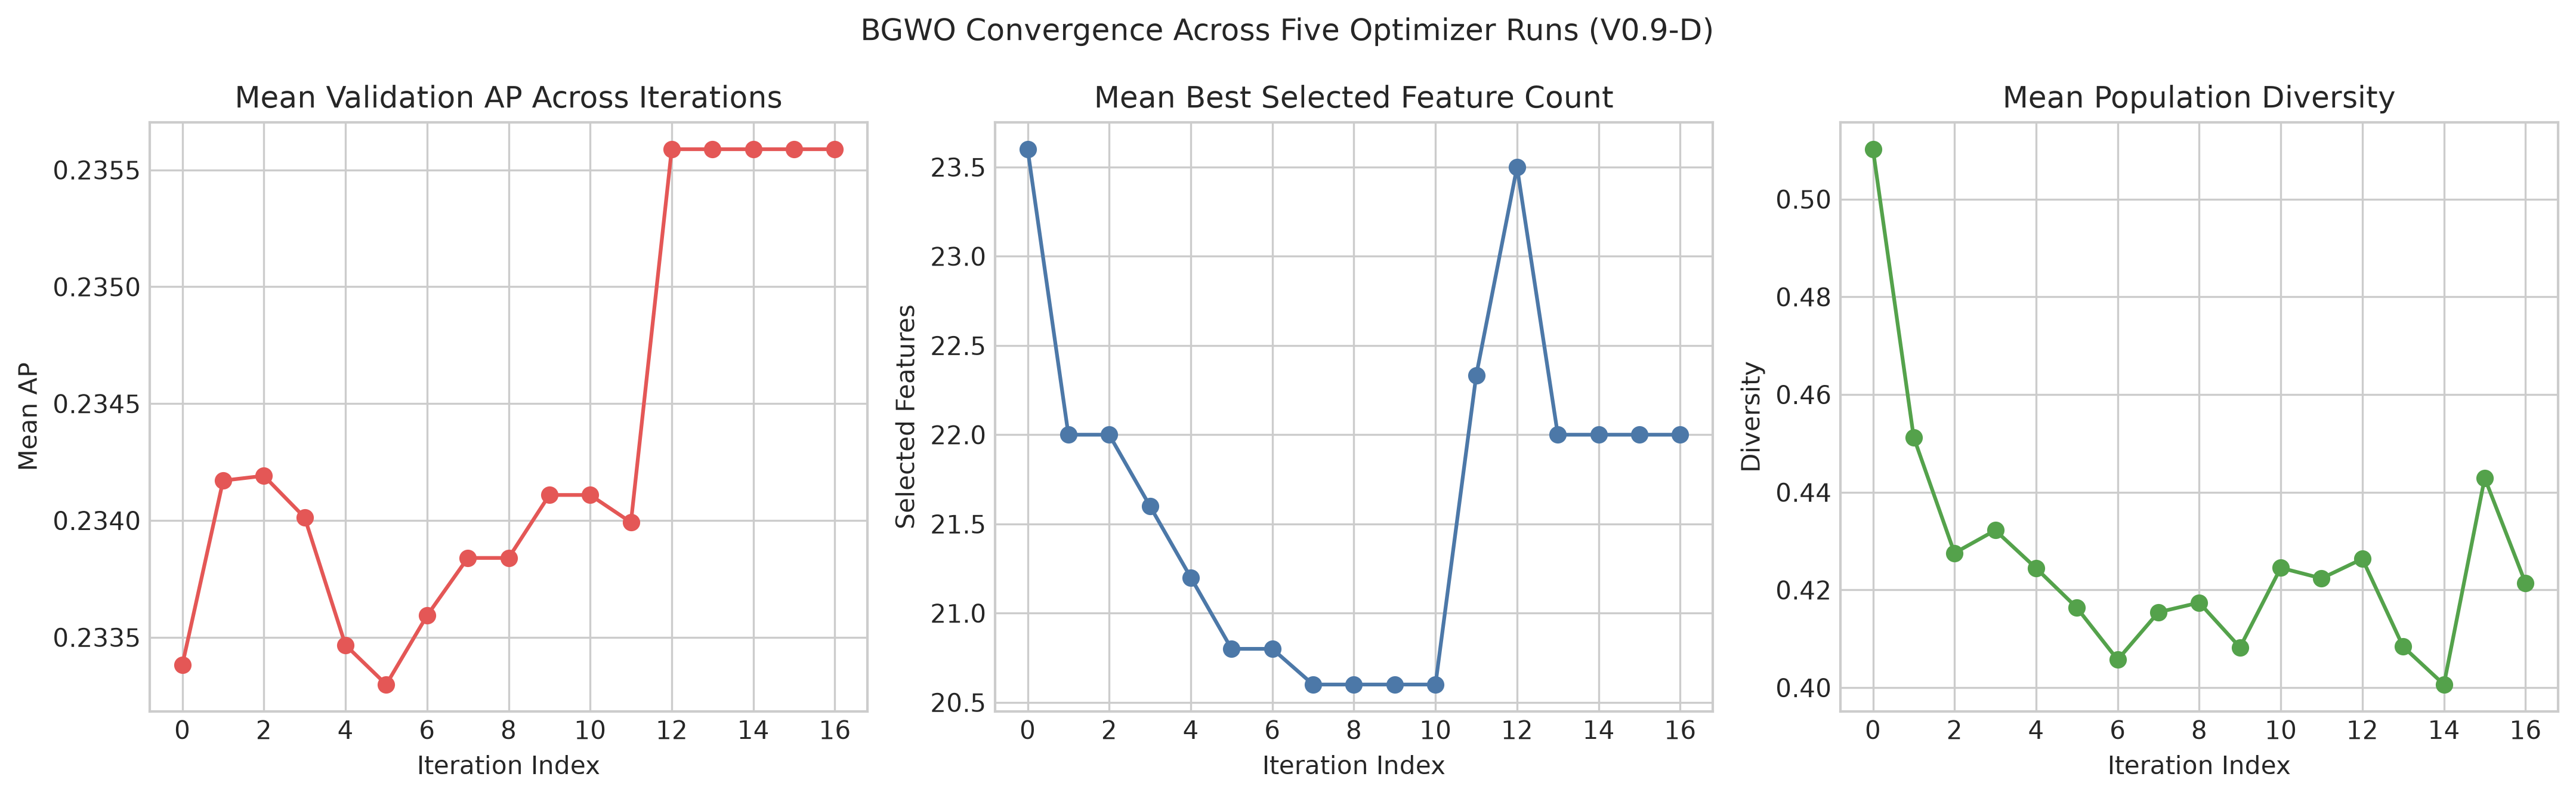

Iterations: 17; feasible runs decline as runs early-stop.


In [5]:
aggregate = pd.DataFrame(
    artifacts["v09d_convergence"]["aggregate_by_iteration"]
).sort_values("iteration_index")
display(aggregate.round(6))
from IPython.display import Image
display(Image(filename=str(FIGURE_DIR / f"{v09g.FIGURE_NAMES[0]}.png")))
print(f"Iterations: {len(aggregate)}; feasible runs decline as runs early-stop.")

## 6. BGWO Feature-Selection Stability (V0.9-D)

Run-to-run stability of selected feature sets across the five optimizer seeds.

,optimizer,metric,mean,median,min,max
0,BGWO,selected_feature_count,20.600000,22.000000,14.00000,25.000000
1,BGWO,pairwise_jaccard,0.363366,0.396429,0.16129,0.566667


,feature,feature_index,selection_count,selection_frequency
32,Department Name_Fan Shop,32,1,0.2
35,Department Name_Footwear,35,1,0.2
41,Department Name_Health and Beauty,41,1,0.2
26,Shipping Mode_Second Class,26,1,0.2
19,Type_CASH,19,1,0.2
17,Type_TRANSFER,17,1,0.2
9,month,9,1,0.2
3,order_item_discount,3,1,0.2
4,order_item_discount_rate,4,1,0.2
29,Customer Segment_Consumer,29,2,0.4


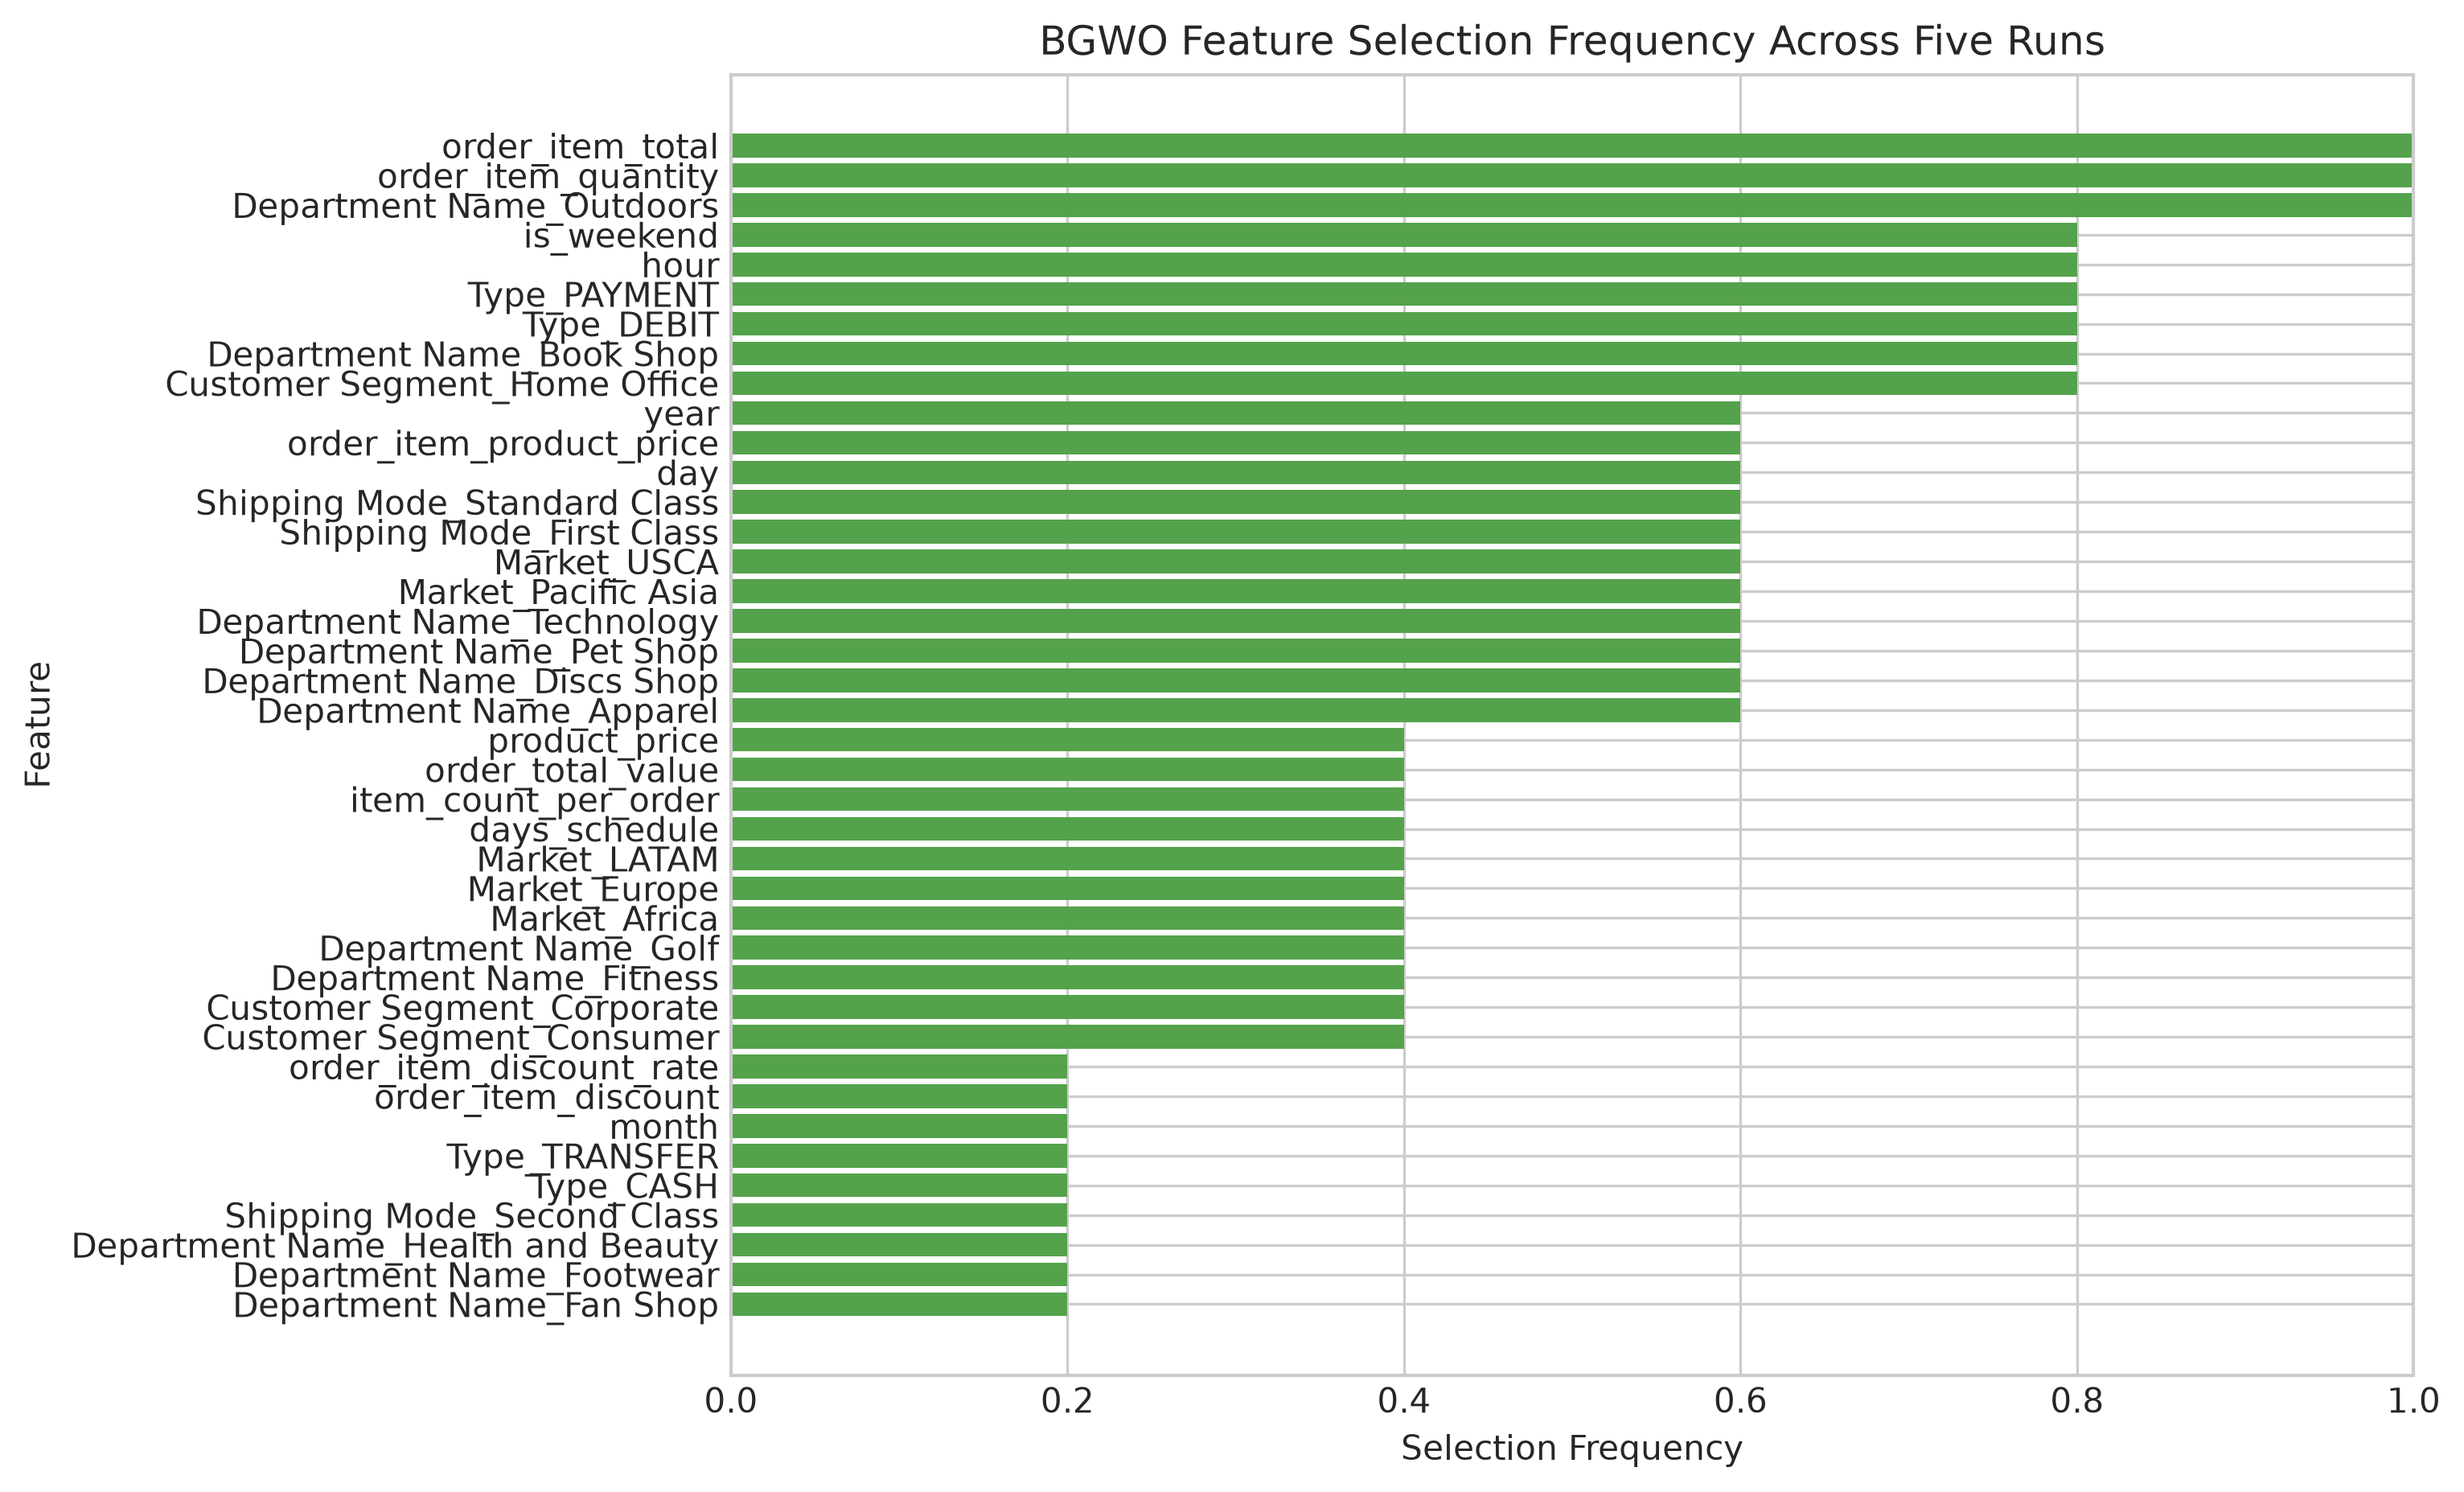

Consensus used for winner selection: False


In [6]:
stability = artifacts["v09d_stability"]
cards = pd.DataFrame([
    {"optimizer": "BGWO", "metric": "selected_feature_count",
     "mean": stability["cardinality"]["mean"],
     "median": stability["cardinality"]["median"],
     "min": stability["cardinality"]["min"],
     "max": stability["cardinality"]["max"]},
    {"optimizer": "BGWO", "metric": "pairwise_jaccard",
     "mean": stability["jaccard"]["mean"],
     "median": stability["jaccard"]["median"],
     "min": stability["jaccard"]["min"],
     "max": stability["jaccard"]["max"]},
])
display(cards)
frequency = pd.DataFrame(stability["feature_frequency"])
frequency = frequency[frequency["selection_count"] > 0].sort_values(
    ["selection_frequency", "feature"], ascending=[True, True]
)
display(frequency)
display(Image(filename=str(FIGURE_DIR / f"{v09g.FIGURE_NAMES[2]}.png")))
print("Consensus used for winner selection:", stability["consensus_used_for_selection"])

## 7. Locked BGWO Winner (V0.9-D)

The governed BGWO winner lock: K=14, seed 2042, validation metrics, and the 43-wide mask.

,property,value
0,optimizer,BGWO
1,selected_feature_count,14
2,source_optimizer_seed,2042
3,validation_average_precision,0.234618
4,validation_f1,0.189644
5,validation_recall,0.322667
6,semantic_lock_sha256,e228f4c619de7e2028e4089723c6ae066fe8c2ab9ed1d9...
7,mask_sha256,7ebb823374255f4f10c737c62a2111604aa50193a8f0d9...
8,selected_features_sha256,0d5219835f3dc96acb3c82f94d286813b834eceefc4156...
9,selection_scope,TRAIN_AND_DEVELOPMENT_VALIDATION_ONLY


Locked BGWO feature set:
  order_item_quantity, product_price, order_item_discount, order_item_discount_rate, order_item_total, days_schedule, is_weekend, item_count_per_order, Market_LATAM, Market_Pacific Asia, Market_USCA, Department Name_Outdoors, Department Name_Discs Shop, Department Name_Book Shop


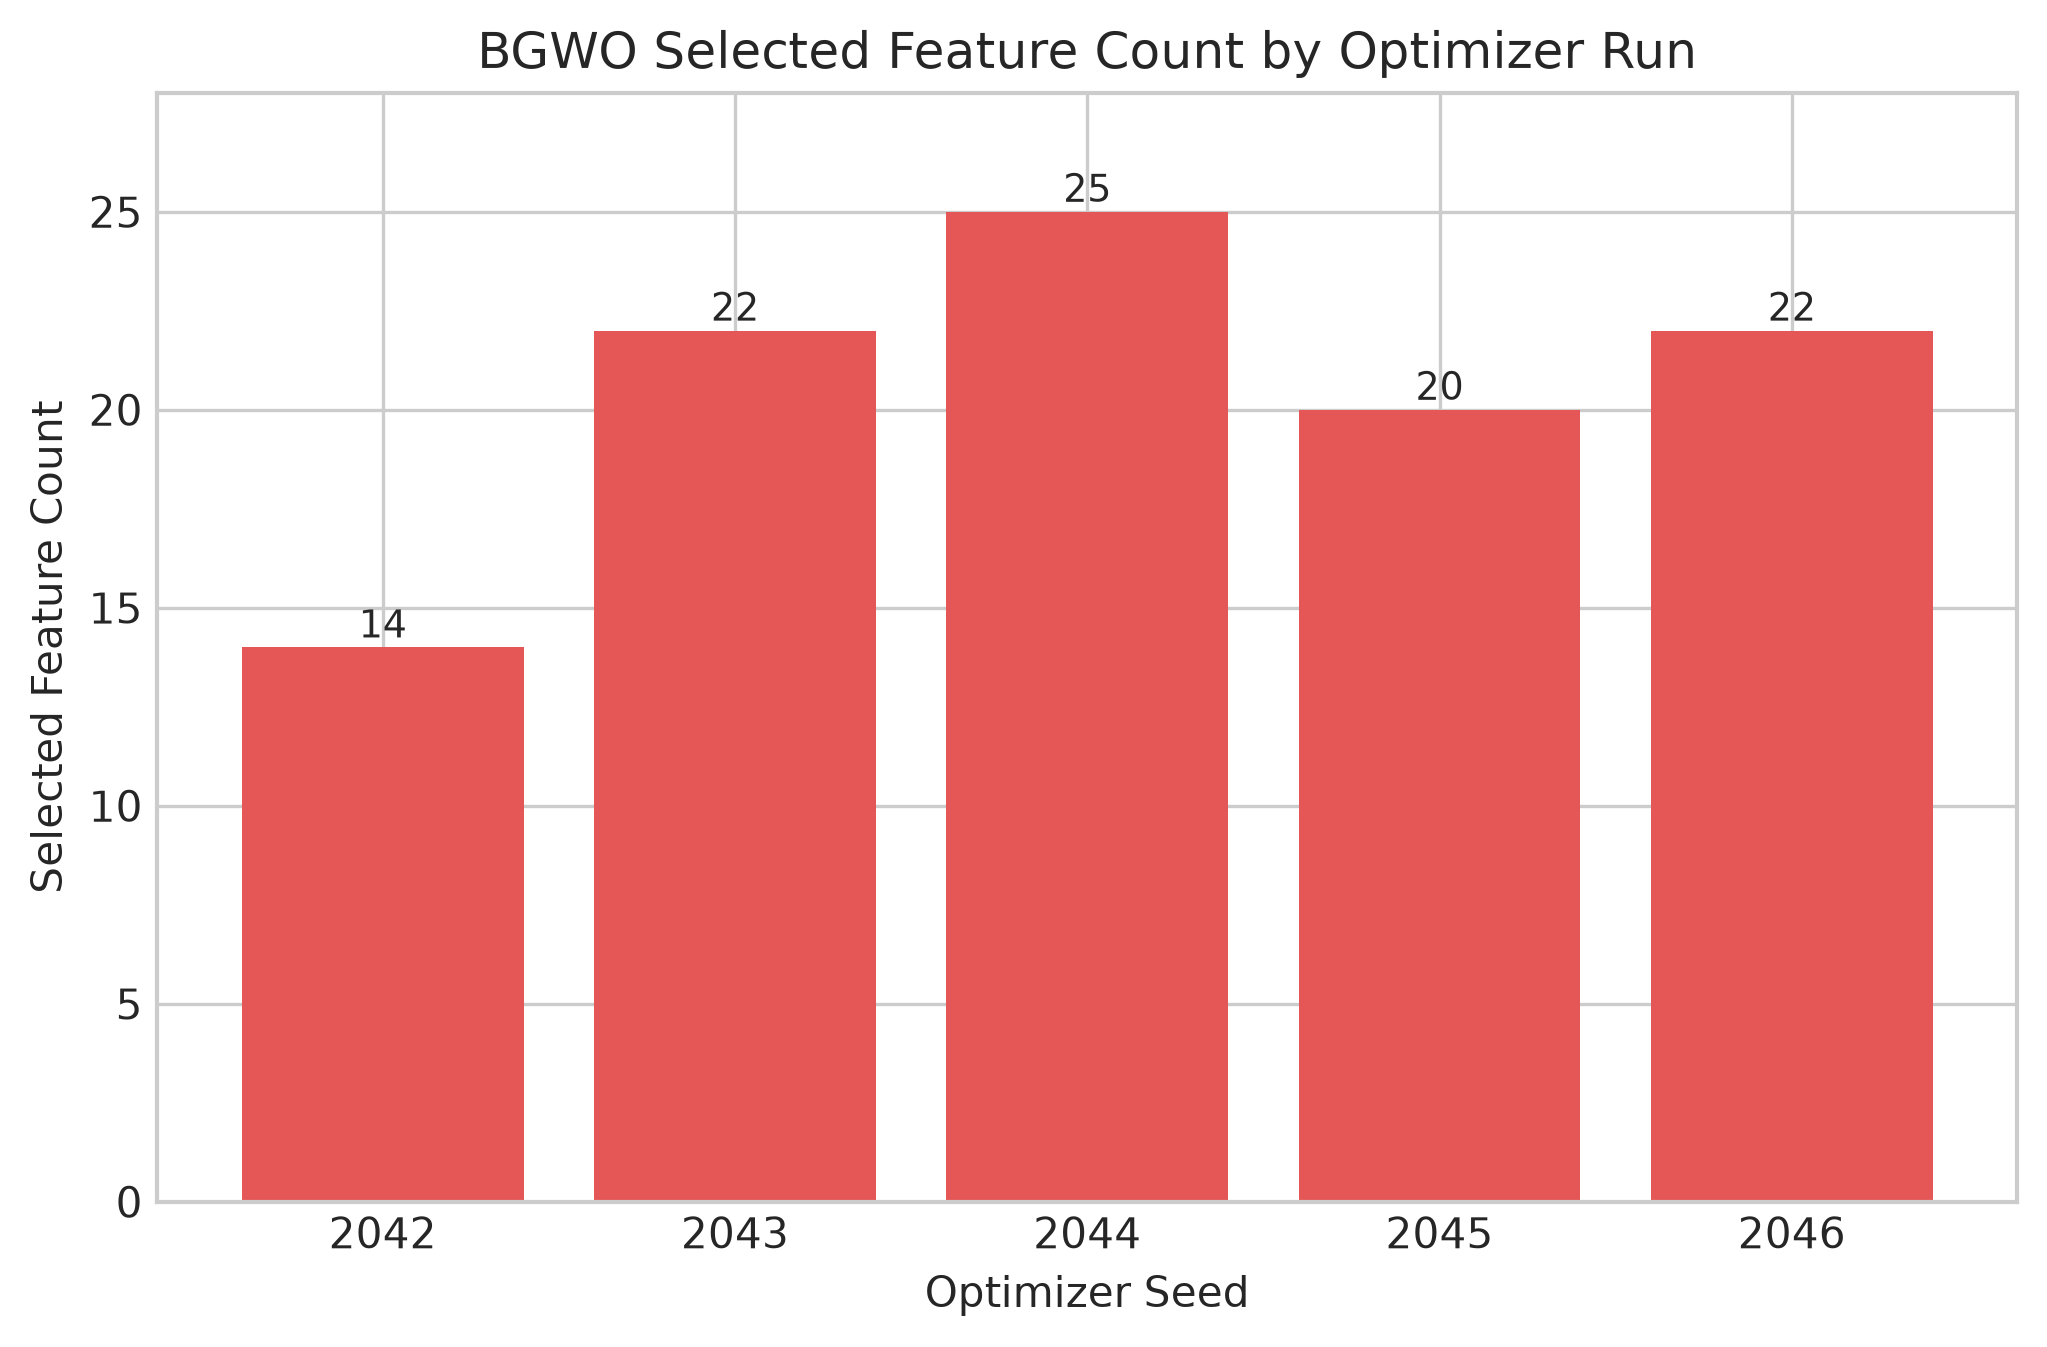

In [7]:
winner_rows = [
    {"property": "optimizer", "value": bgwo_lock["optimizer"]},
    {"property": "selected_feature_count", "value": int(bgwo_lock["selected_feature_count"])},
    {"property": "source_optimizer_seed", "value": int(bgwo_lock["source_optimizer_seed"])},
    {"property": "validation_average_precision", "value": bgwo_lock["validation_metrics"]["average_precision"]},
    {"property": "validation_f1", "value": bgwo_lock["validation_metrics"]["f1"]},
    {"property": "validation_recall", "value": bgwo_lock["validation_metrics"]["recall"]},
    {"property": "semantic_lock_sha256", "value": bgwo_lock["semantic_lock_sha256"]},
    {"property": "mask_sha256", "value": bgwo_lock["mask_sha256"]},
    {"property": "selected_features_sha256", "value": bgwo_lock["selected_features_sha256"]},
    {"property": "selection_scope", "value": bgwo_lock["selection_scope"]},
    {"property": "final_test_accessed", "value": bgwo_lock["final_test_accessed"]},
]
display(pd.DataFrame(winner_rows))
bgwo_features = bgwo_lock["ordered_selected_features"]
print("Locked BGWO feature set:")
print("  " + ", ".join(bgwo_features))
display(Image(filename=str(FIGURE_DIR / f"{v09g.FIGURE_NAMES[1]}.png")))

## 8. BPSO Reference Context (frozen V0.8 evidence)

The governed V0.8-C BPSO winner (K=10, seed 1042) is used as a frozen metaheuristic reference. BPSO/BGWO language is comparative and metric-specific only; no overall winner is asserted.

In [8]:
bpso_ref_rows = [
    {"property": "selected_feature_count", "value": int(bpso_lock["selected_feature_count"])},
    {"property": "source_optimizer_seed", "value": int(bpso_lock["source_optimizer_seed"])},
    {"property": "validation_average_precision", "value": bpso_lock["validation_metrics"]["average_precision"]},
    {"property": "validation_f1", "value": bpso_lock["validation_metrics"]["f1"]},
    {"property": "validation_recall", "value": bpso_lock["validation_metrics"]["recall"]},
    {"property": "semantic_lock_sha256", "value": bpso_lock["semantic_lock_sha256"]},
    {"property": "selection_scope", "value": bpso_lock["selection_scope"]},
    {"property": "final_test_accessed", "value": bpso_lock["final_test_accessed"]},
]
display(pd.DataFrame(bpso_ref_rows))
bpso_features = bpso_lock["ordered_selected_features"]
print("Locked BPSO feature set:")
print("  " + ", ".join(bpso_features))

,property,value
0,selected_feature_count,10
1,source_optimizer_seed,1042
2,validation_average_precision,0.230285
3,validation_f1,0.203308
4,validation_recall,0.318667
5,semantic_lock_sha256,0f356ccab422774b128ab82f5da8881f24816902d4ccc6...
6,selection_scope,TRAIN_AND_DEVELOPMENT_VALIDATION_ONLY
7,final_test_accessed,False


Locked BPSO feature set:
  order_item_quantity, order_item_profit_ratio, order_item_total, hour, Type_PAYMENT, Market_LATAM, Shipping Mode_Same Day, Customer Segment_Corporate, Department Name_Apparel, Department Name_Health and Beauty


## 9. Feature Overlap: BGWO vs BPSO-K10 and BGWO vs MI-K11

Set-level overlap from `v09e_feature_overlap.json`. MI-K11 is seed-specific, so its row is a mean across the five MI seeds.

In [9]:
overlap = artifacts["v09e_feature_overlap"]
bg_vs_bpso = overlap["bgwo_vs_bpso"]
bg_vs_mi = overlap["bgwo_vs_mi_k11"]
mi_seeds = bg_vs_mi["per_seed"]
overlap_rows = [
    {"pair": "BGWO vs BPSO-K10",
     "intersection_size": bg_vs_bpso["intersection_size"],
     "union_size": bg_vs_bpso["union_size"],
     "jaccard": round(bg_vs_bpso["jaccard"], 6),
     "shared": ", ".join(bg_vs_bpso["shared_features"]),
     "bgwo_only_count": len(bg_vs_bpso["bgwo_only_features"]),
     "other_only_count": len(bg_vs_bpso["bpso_only_features"])},
    {"pair": "BGWO vs MI-K11 (mean of 5 seeds)",
     "intersection_size": round(sum(s["intersection_size"] for s in mi_seeds) / len(mi_seeds), 3),
     "union_size": round(sum(s["union_size"] for s in mi_seeds) / len(mi_seeds), 3),
     "jaccard": round(bg_vs_mi["union_jaccard"], 6),
     "shared": f"mean seed jaccard {bg_vs_mi['mean_seed_jaccard']:.6f}; per-seed sets vary",
     "bgwo_only_count": "",
     "other_only_count": ""},
]
display(pd.DataFrame(overlap_rows))
assert bg_vs_bpso["intersection_size"] == 3
assert abs(bg_vs_bpso["jaccard"] - 0.14285714285714285) < 1e-12

,pair,intersection_size,union_size,jaccard,shared,bgwo_only_count,other_only_count
0,BGWO vs BPSO-K10,3.0,21.0,0.142857,"order_item_quantity, order_item_total, Market_...",11,7
1,BGWO vs MI-K11 (mean of 5 seeds),6.4,18.6,0.347826,mean seed jaccard 0.345029; per-seed sets vary,,


## 10. Final-Test Predictive Evaluation (V0.9-E)

Final-test means for the two classifiers (BGWO vs frozen references). Tables and figures were regenerated once in section 4 from the frozen V0.9-E evidence.

,configuration_id,mean_average_precision,std_average_precision,mean_f1,std_f1,mean_recall,std_recall,mean_precision,std_precision,mean_roc_auc,std_roc_auc
0,K43,0.222084,0.004786,0.189005,0.071311,0.305333,0.142334,0.265385,0.294347,0.603533,0.011182
1,K42,0.222084,0.004786,0.189005,0.071311,0.305333,0.142334,0.265385,0.294347,0.603533,0.011182
2,MI-K11,0.224941,0.006803,0.192121,0.072666,0.300000,0.149944,0.293470,0.319997,0.605495,0.009091
3,BPSO-K10,0.219612,0.006331,0.187258,0.069757,0.298667,0.153598,0.245874,0.229774,0.599909,0.010907
4,BGWO,0.226035,0.006355,0.179717,0.056176,0.308000,0.137550,0.171505,0.103005,0.605750,0.009521


,configuration_id,mean_average_precision,std_average_precision,mean_f1,std_f1,mean_recall,std_recall,mean_precision,std_precision,mean_roc_auc,std_roc_auc
0,K43,0.051150,0.003093,0.087348,0.005279,0.423333,0.078245,0.048824,0.002543,0.494000,0.015422
1,K42,0.051150,0.003092,0.087348,0.005279,0.423333,0.078245,0.048824,0.002543,0.493999,0.015420
2,MI-K11,0.051171,0.002839,0.092457,0.003344,0.510000,0.067454,0.050907,0.001909,0.500645,0.016848
3,BPSO-K10,0.050732,0.002845,0.086940,0.002979,0.468000,0.048626,0.047949,0.001480,0.489860,0.006800
4,BGWO,0.050810,0.004138,0.088486,0.005803,0.468000,0.111769,0.049015,0.002391,0.490500,0.019945


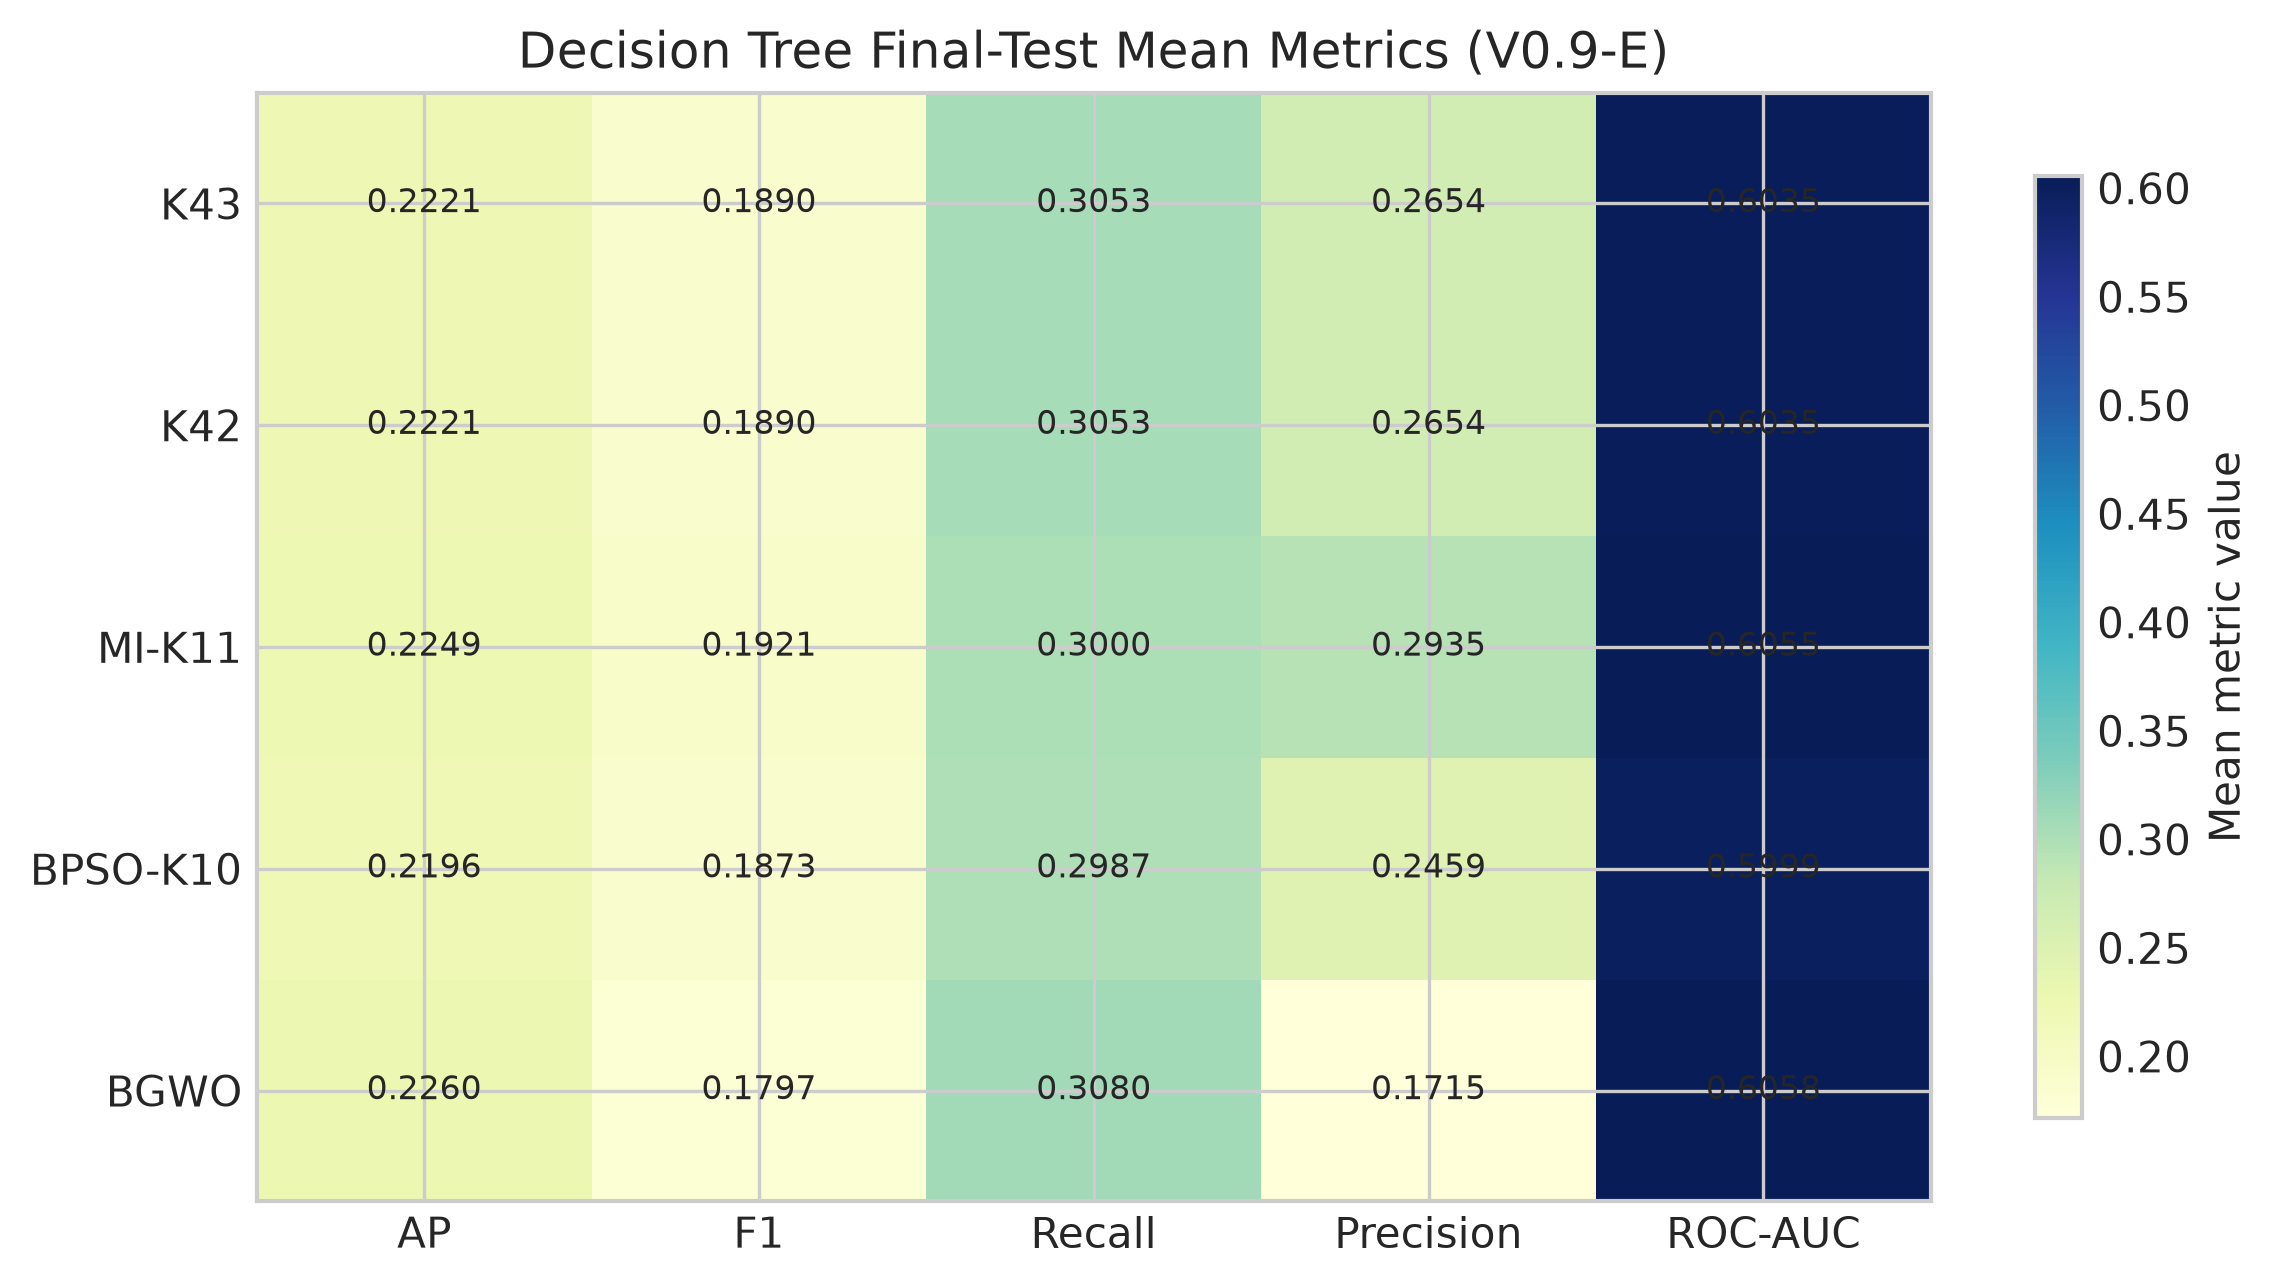

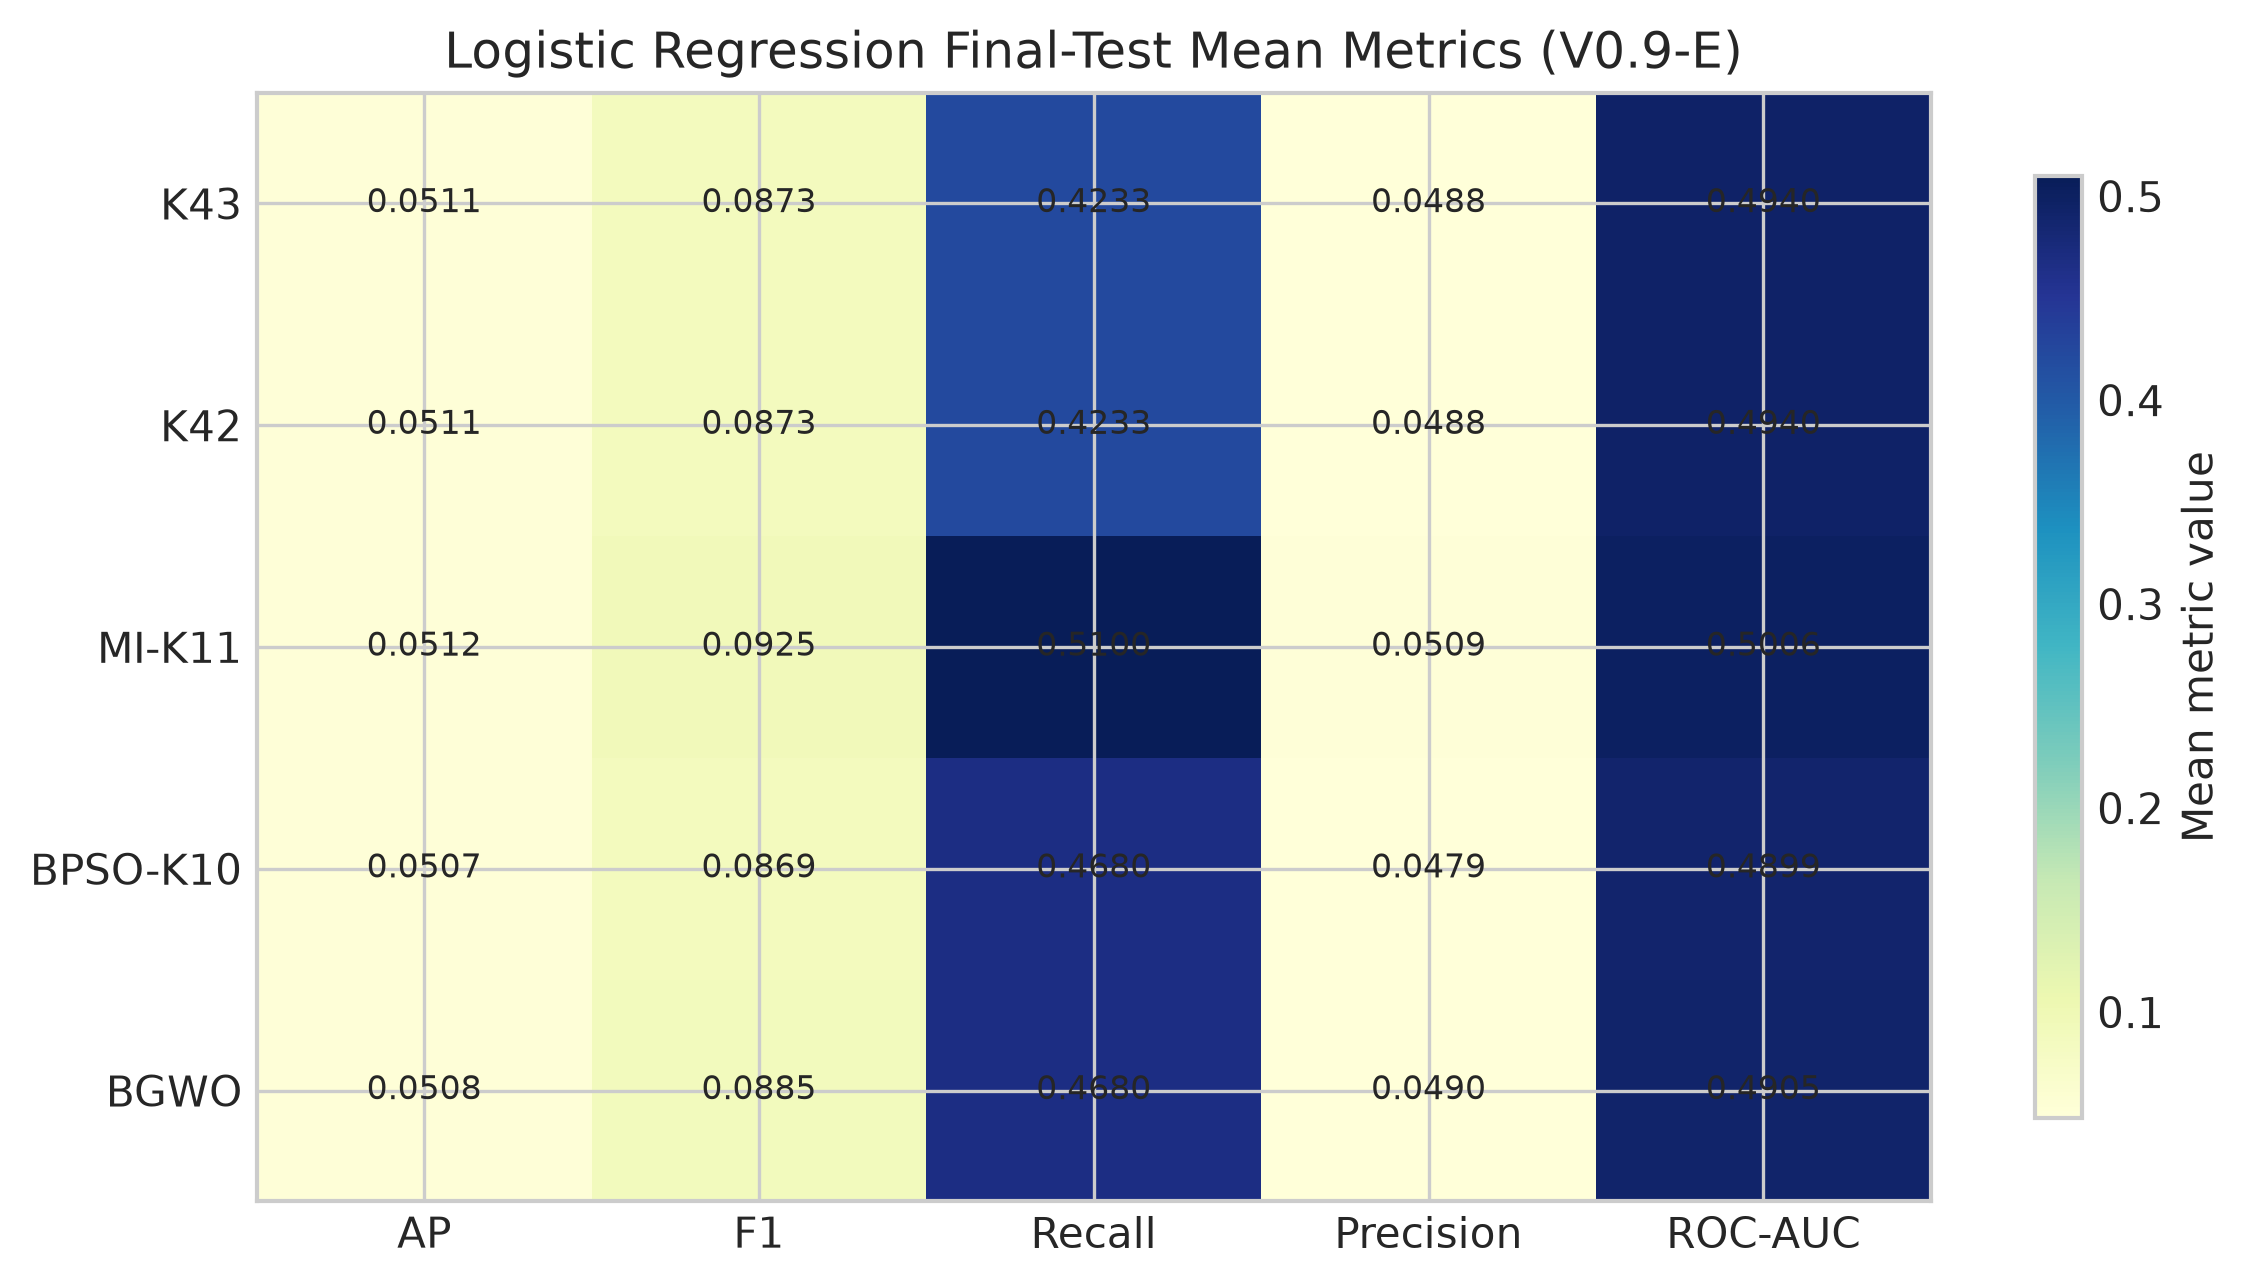

In [10]:
final_dt = pd.read_csv(TABLE_DIR / v09g.TABLE_FILENAMES["final_test_dt"])
final_lr = pd.read_csv(TABLE_DIR / v09g.TABLE_FILENAMES["final_test_lr"])
display(final_dt.round(6))
display(final_lr.round(6))
display(Image(filename=str(FIGURE_DIR / f"{v09g.FIGURE_NAMES[4]}.png")))
display(Image(filename=str(FIGURE_DIR / f"{v09g.FIGURE_NAMES[5]}.png")))

## 11. Paired Statistical Comparisons (V0.9-E)

Paired 95% CIs of BGWO minus each reference (n=5 model/attack seed pairs), per classifier per metric.

,classifier,candidate_configuration_id,reference_configuration_id,metric,n,df,mean_difference,std_difference,ci95_low,ci95_high,direction_uncertain
5,decision_tree,BGWO,BPSO-K10,average_precision,5,4,0.006423,0.004118,0.001310,0.011536,False
6,decision_tree,BGWO,BPSO-K10,f1,5,4,-0.007541,0.025265,-0.038912,0.023829,True
8,decision_tree,BGWO,BPSO-K10,recall,5,4,0.009333,0.024427,-0.020996,0.039663,True
20,logistic_regression,BGWO,BPSO-K10,average_precision,5,4,0.000079,0.003897,-0.004761,0.004918,True
21,logistic_regression,BGWO,BPSO-K10,f1,5,4,0.001546,0.007510,-0.007779,0.010870,True
23,logistic_regression,BGWO,BPSO-K10,recall,5,4,-0.000000,0.115133,-0.142956,0.142956,True


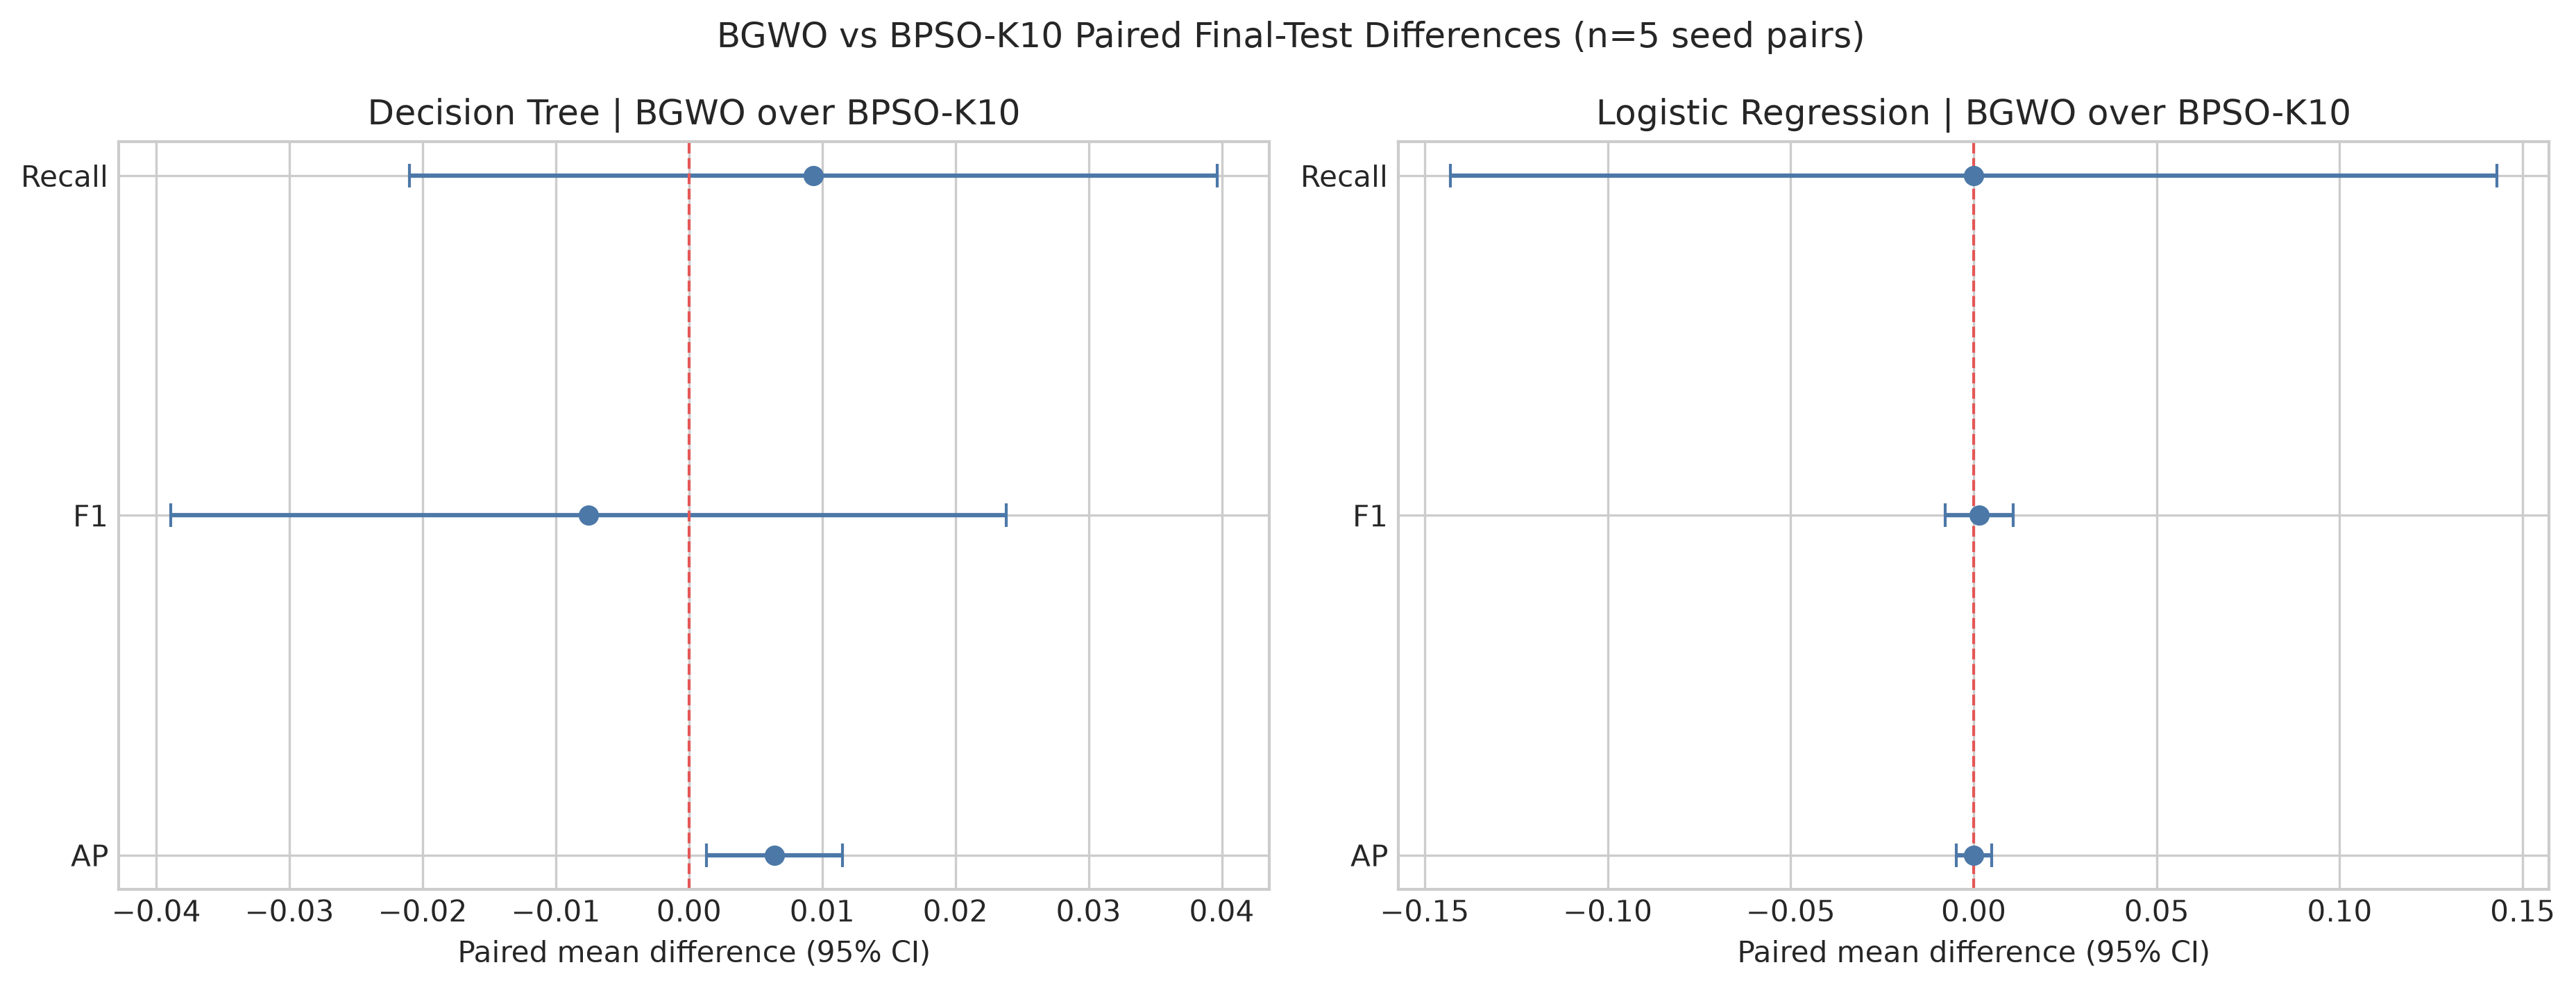

DT AP BGWO vs BPSO-K10 95% CI: (np.float64(0.0013098820602024), np.float64(0.0115364328426705))
DT F1 BGWO vs BPSO-K10 95% CI crosses zero: True
DT AP BGWO vs BPSO-K10 95% CI includes zero: False


In [11]:
paired = pd.read_csv(TABLE_DIR / v09g.TABLE_FILENAMES["paired_statistics"])
view = paired[(paired["metric"].isin(["average_precision", "f1", "recall"])) & (paired["reference_configuration_id"] == "BPSO-K10")]
display(view.round(6))
display(Image(filename=str(FIGURE_DIR / f"{v09g.FIGURE_NAMES[6]}.png")))
dt_ap = paired[(paired["classifier"] == "decision_tree") & (paired["metric"] == "average_precision") & (paired["reference_configuration_id"] == "BPSO-K10")].iloc[0]
dt_f1 = paired[(paired["classifier"] == "decision_tree") & (paired["metric"] == "f1") & (paired["reference_configuration_id"] == "BPSO-K10")].iloc[0]
print("DT AP BGWO vs BPSO-K10 95% CI:", (dt_ap["ci95_low"], dt_ap["ci95_high"]))
print("DT F1 BGWO vs BPSO-K10 95% CI crosses zero:", dt_f1["ci95_low"] <= 0.0 <= dt_f1["ci95_high"])
print("DT AP BGWO vs BPSO-K10 95% CI includes zero:", dt_ap["ci95_low"] <= 0.0 <= dt_ap["ci95_high"])

## 12. Validation vs Final-Test Preservation

Frozen V0.9-E preservation analysis: preregistered descriptive margins (AP loss <= 5%, F1 loss <= 5%, Recall loss <= 10%) are operational, not domain-validated, and the final test was never used to reselect or retune.

In [12]:
preservation = artifacts["v09e_preservation"]
pres_rows = [
    {"item": "margin_average_precision", "value": preservation["margins"]["average_precision"]},
    {"item": "margin_f1", "value": preservation["margins"]["f1"]},
    {"item": "margin_recall", "value": preservation["margins"]["recall"]},
    {"item": "cross_classifier_interpretation", "value": preservation["cross_classifier_interpretation"]},
    {"item": "winner_reselection_performed", "value": preservation["winner_reselection_performed"]},
    {"item": "domain_validated_margins", "value": preservation["domain_validated_margins"]},
]
display(pd.DataFrame(pres_rows))
for r in preservation["results"]:
    summary = {c["metric"]: (c["preserved"], round(c["relative_change"], 4)) for c in r["metric_checks"][:3]}
    print(r["classifier"], "overall_preserved:", r["overall_preserved"], summary)

,item,value
0,margin_average_precision,0.05
1,margin_f1,0.05
2,margin_recall,0.1
3,cross_classifier_interpretation,PRESERVATION_HOLDS_FOR_BOTH_CLASSIFIERS
4,winner_reselection_performed,False
5,domain_validated_margins,False


decision_tree overall_preserved: True {'average_precision': (True, 0.0178), 'f1': (True, -0.0491), 'recall': (True, 0.0087)}
logistic_regression overall_preserved: True {'average_precision': (True, -0.0066), 'f1': (True, 0.013), 'recall': (True, 0.1055)}


## 13. Resource Efficiency: Training (V0.9-F)

`DIRECT_ENERGY_UNAVAILABLE`. Wall time, CPU time, RSS and input-memory are computational resource proxies; serialized model size is structural.

,classifier,configuration_id,feature_count,training_wall_time_sec,training_cpu_time_sec,training_absolute_rss_mib,training_input_memory_bytes,serialized_model_bytes
0,decision_tree,K43,43,13.149721,0.101427,166.723906,9632132.0,4436.0
1,decision_tree,K42,42,13.453628,0.100579,166.380312,9408132.0,4420.0
2,decision_tree,MI-K11,11,13.427421,0.051575,156.392656,2464132.0,3700.0
3,decision_tree,BPSO-K10,10,12.915537,0.037560,156.154453,2240132.0,3732.0
4,decision_tree,BGWO,14,12.623808,0.042042,157.324219,3136132.0,3812.0
5,logistic_regression,K43,43,13.236930,0.249659,182.445547,9632132.0,2358.0
6,logistic_regression,K42,42,12.870803,0.226766,181.593750,9408132.0,2326.0
7,logistic_regression,MI-K11,11,12.715085,0.037735,164.459609,2464132.0,1366.0
8,logistic_regression,BPSO-K10,10,12.468882,0.049475,161.633672,2240132.0,1382.0
9,logistic_regression,BGWO,14,12.215133,0.071571,164.833672,3136132.0,1494.0


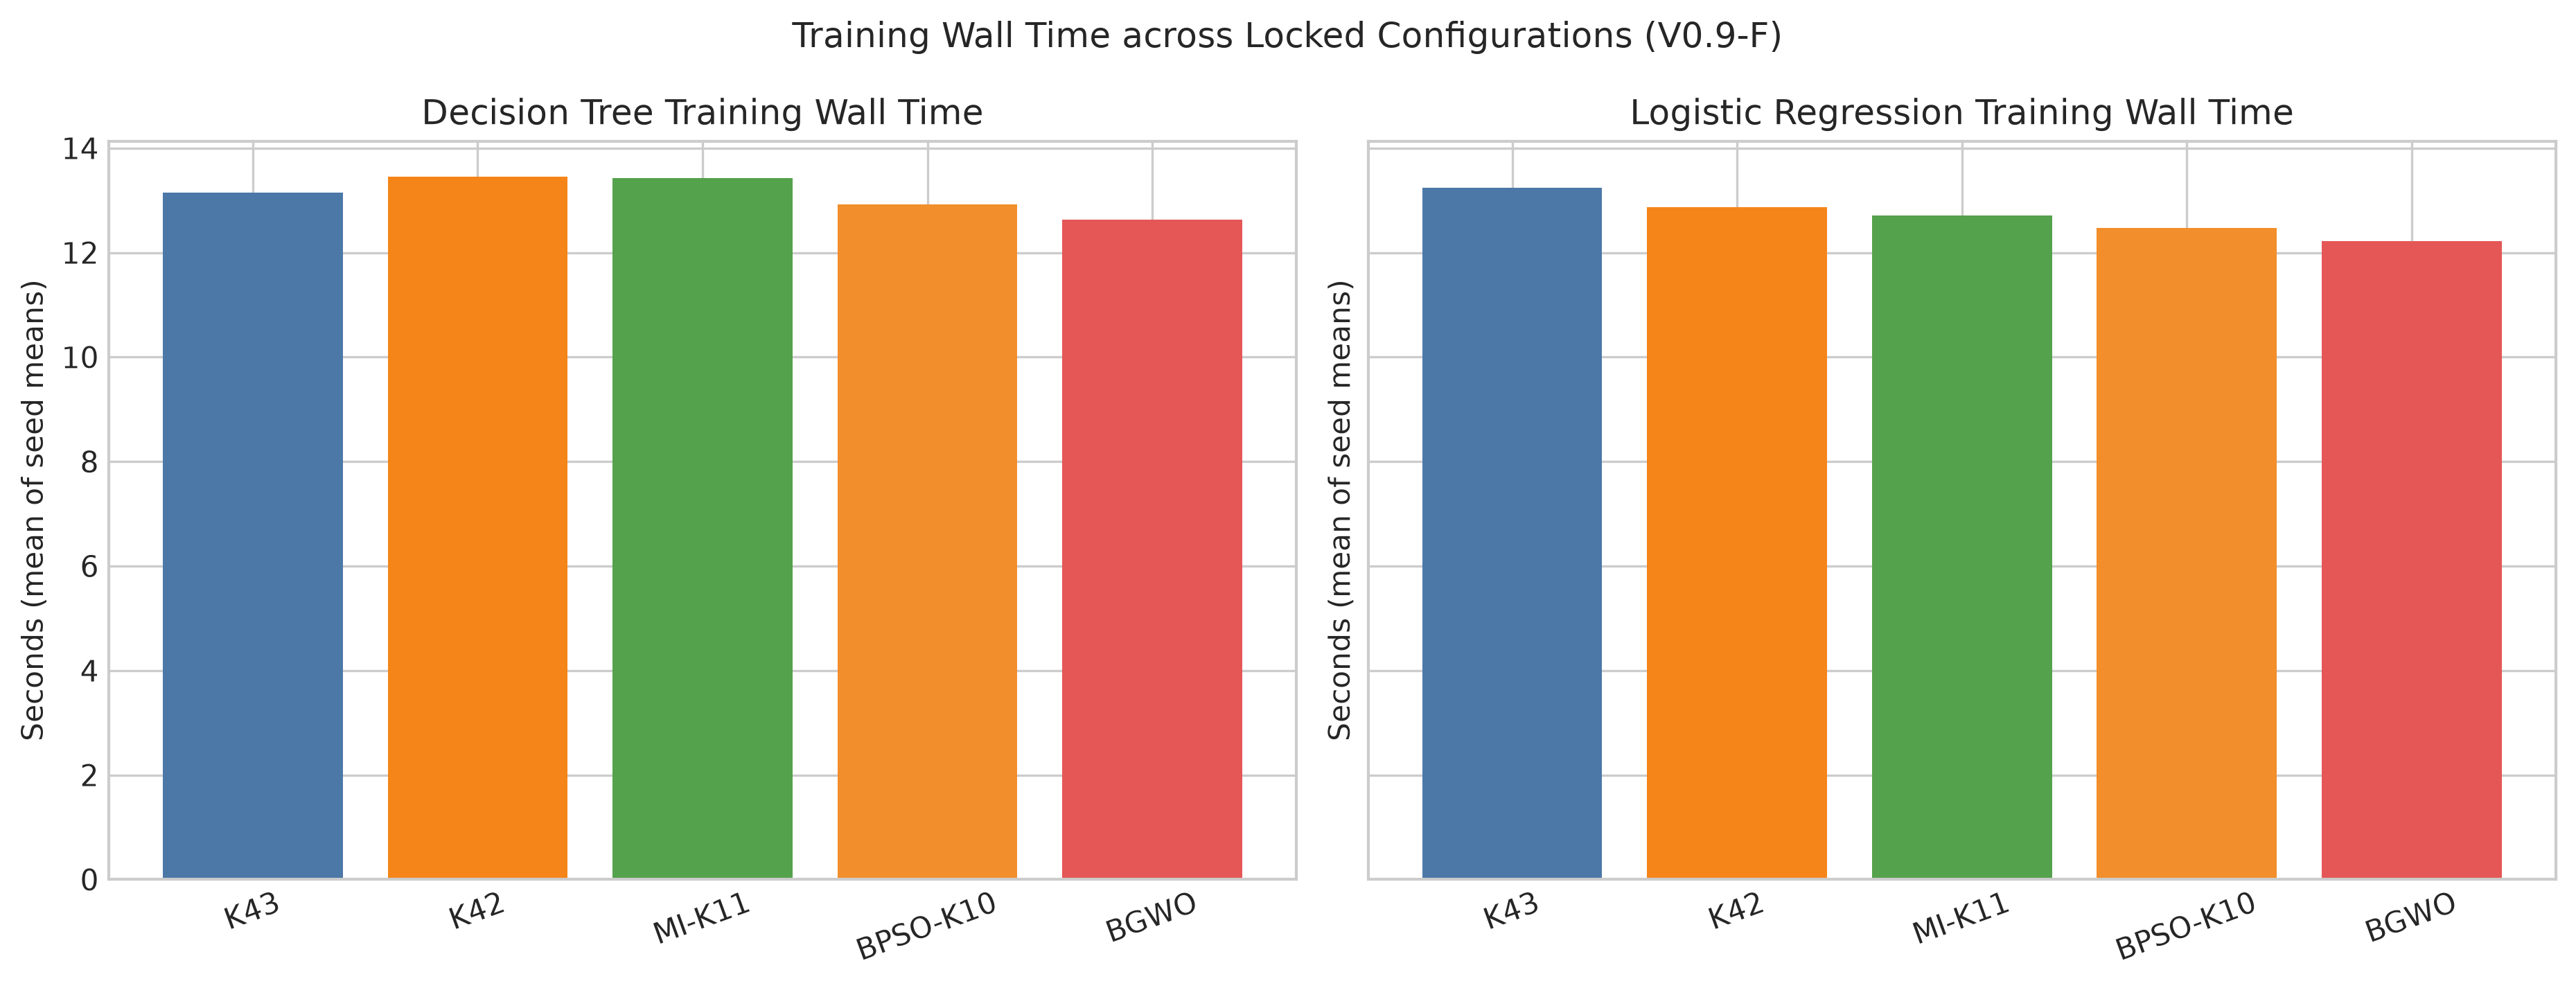

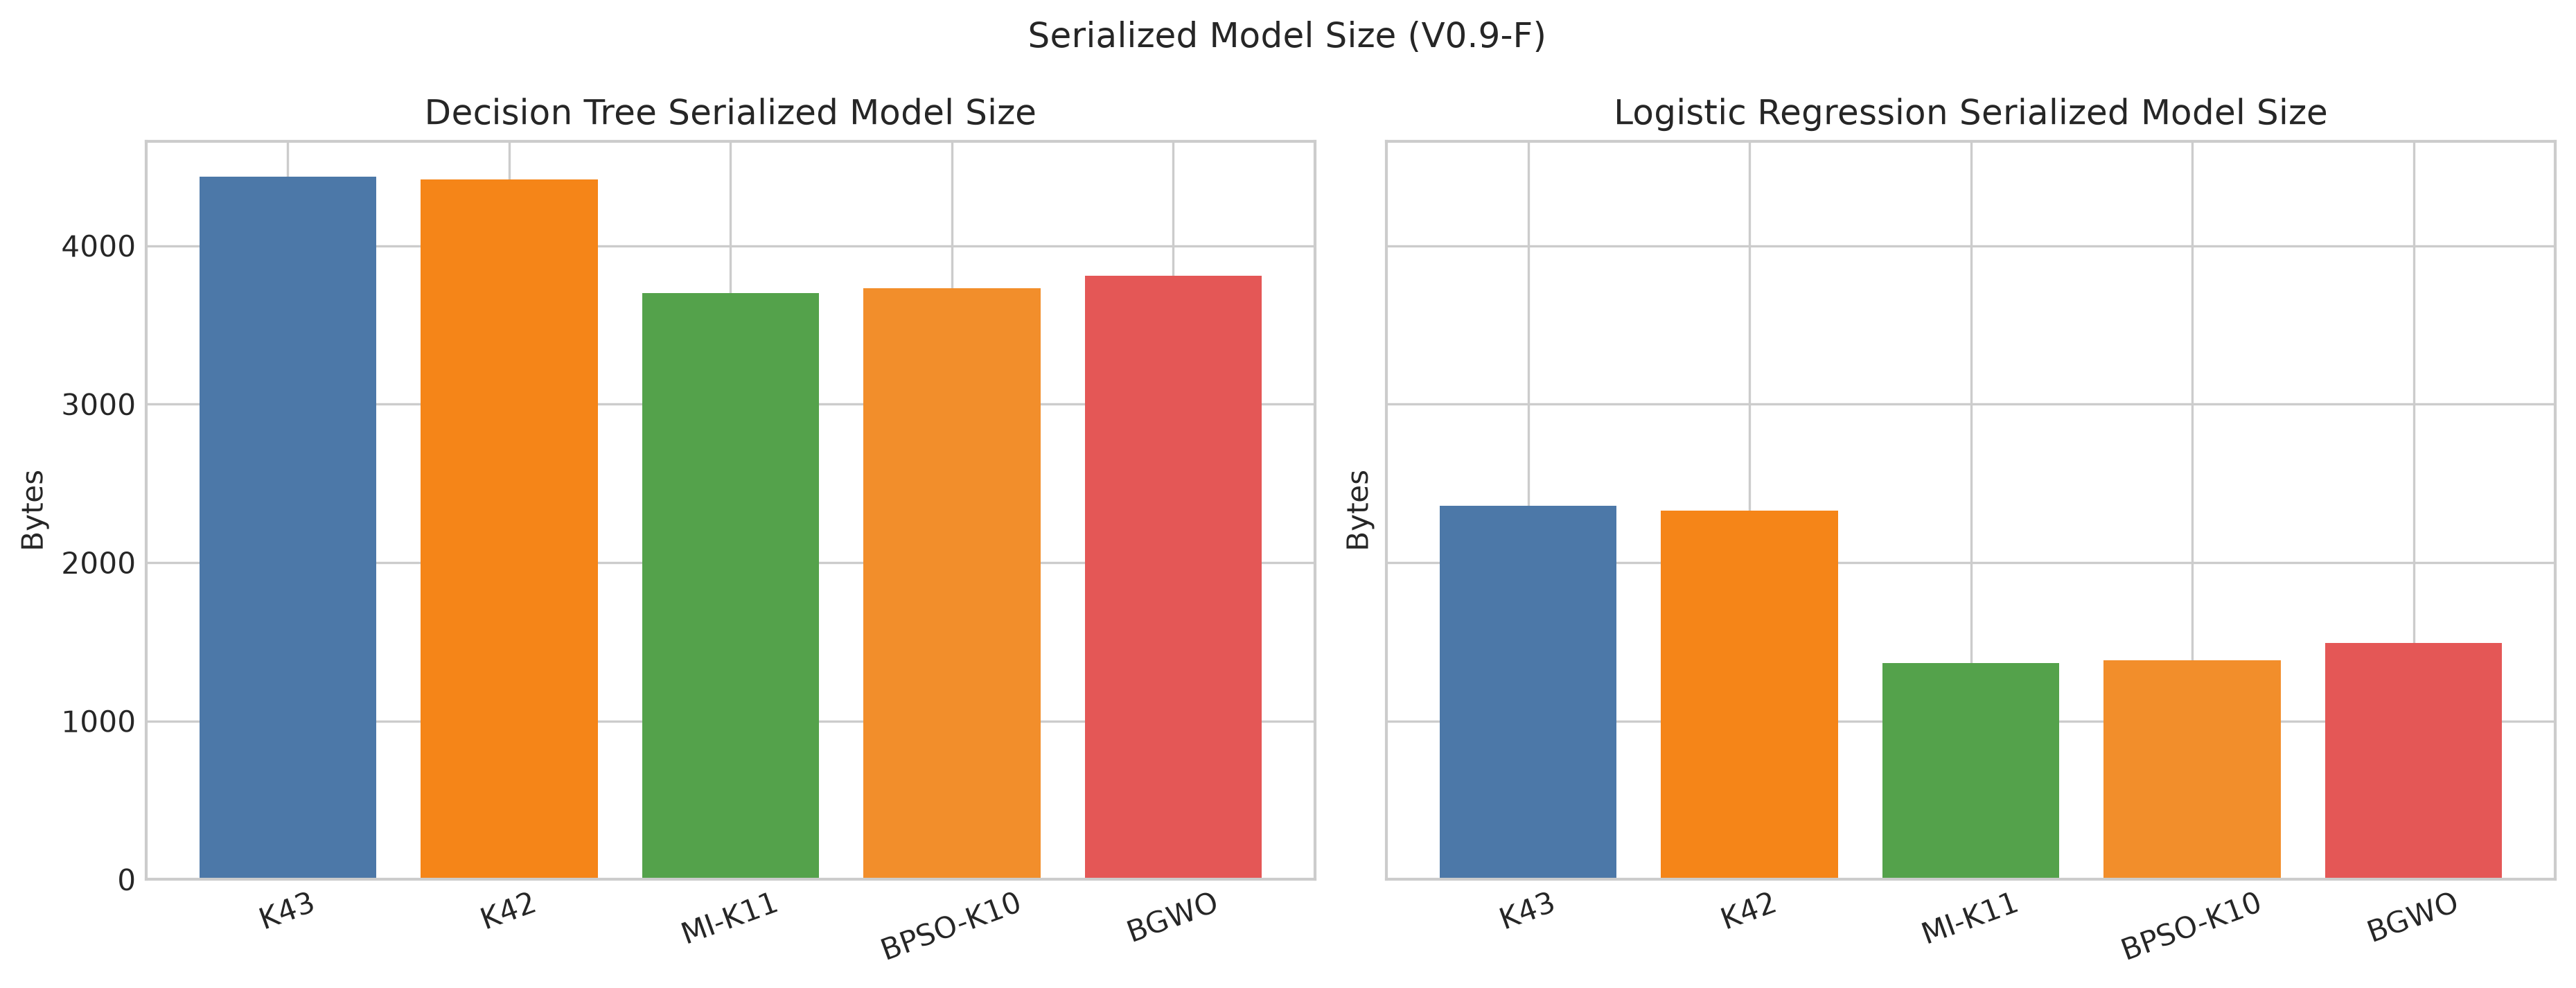

DT BGWO training wall time (mean of seed means): 12.6238 s
DT BGWO serialized model size: 3812 bytes


In [13]:
resource = pd.read_csv(TABLE_DIR / v09g.TABLE_FILENAMES["resource_efficiency"])
training_cols = ["classifier", "configuration_id", "feature_count", "training_wall_time_sec", "training_cpu_time_sec", "training_absolute_rss_mib", "training_input_memory_bytes", "serialized_model_bytes"]
display(resource[training_cols].round(6))
display(Image(filename=str(FIGURE_DIR / f"{v09g.FIGURE_NAMES[7]}.png")))
display(Image(filename=str(FIGURE_DIR / f"{v09g.FIGURE_NAMES[9]}.png")))
dt_bgwo = resource[(resource["classifier"] == "decision_tree") & (resource["configuration_id"] == "BGWO")].iloc[0]
print(f"DT BGWO training wall time (mean of seed means): {dt_bgwo['training_wall_time_sec']:.4f} s")
print(f"DT BGWO serialized model size: {dt_bgwo['serialized_model_bytes']:.0f} bytes")

## 14. Inference Latency and Throughput

Per-record latency and throughput from the frozen V0.9-F resource summary.

,classifier,configuration_id,feature_count,inference_latency_per_record_sec,inference_throughput_records_sec,inference_absolute_rss_mib,inference_input_memory_bytes
0,decision_tree,K43,43,0.0,2.141577e+06,156.853203,2064132.0
1,decision_tree,K42,42,0.0,2.214310e+06,156.777031,2016132.0
2,decision_tree,MI-K11,11,0.0,2.876241e+06,154.646719,528132.0
3,decision_tree,BPSO-K10,10,0.0,3.011770e+06,154.557188,480132.0
4,decision_tree,BGWO,14,0.0,2.955662e+06,154.792422,672132.0
5,logistic_regression,K43,43,0.0,2.440569e+06,155.933281,2064132.0
6,logistic_regression,K42,42,0.0,2.481874e+06,155.852891,2016132.0
7,logistic_regression,MI-K11,11,0.0,3.258592e+06,154.203984,528132.0
8,logistic_regression,BPSO-K10,10,0.0,3.293039e+06,154.165703,480132.0
9,logistic_regression,BGWO,14,0.0,3.131517e+06,154.377734,672132.0


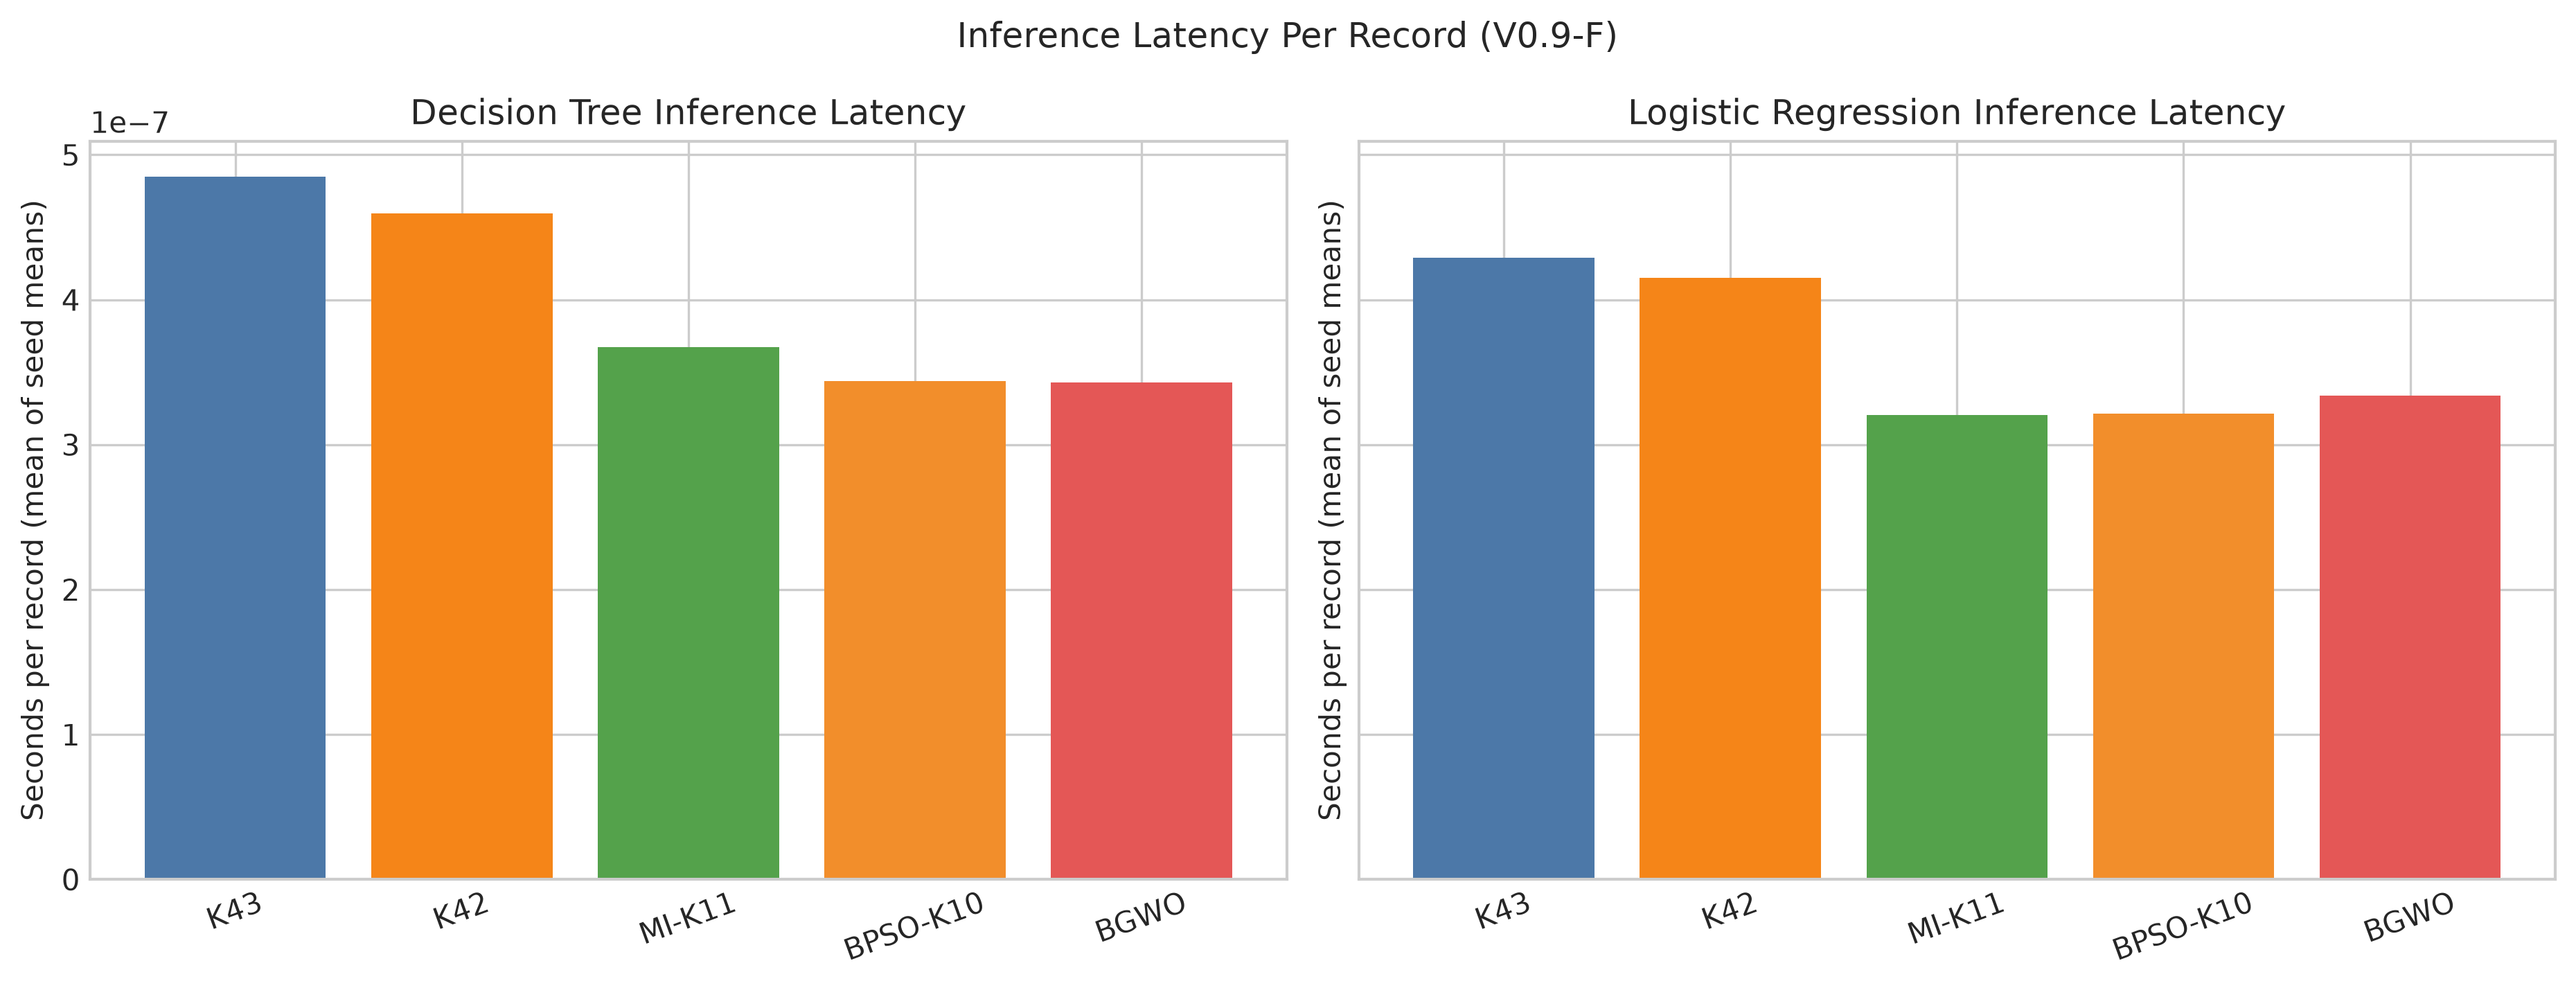

Latency is a timing proxy; it is NOT an energy measurement.


In [14]:
inference_cols = ["classifier", "configuration_id", "feature_count", "inference_latency_per_record_sec", "inference_throughput_records_sec", "inference_absolute_rss_mib", "inference_input_memory_bytes"]
display(resource[inference_cols].round(6))
display(Image(filename=str(FIGURE_DIR / f"{v09g.FIGURE_NAMES[8]}.png")))
print("Latency is a timing proxy; it is NOT an energy measurement.")

## 15. One-Time Optimizer Overhead

Historical search cost, imported (never rerun) and reported separately from recurring resource use.

,optimizer,optimizer_runs,candidate_requests,unique_evaluations,decision_tree_fits,optimizer_wall_time_sec,optimizer_cpu_time_sec,pipeline_wall_time_sec,cache_hits,provenance,source_stage
0,BGWO,5,768,768,3840,325.425443,325.253787,111.891058,0,IMPORTED_HISTORICAL,V0.9-D
1,BPSO,5,972,972,4860,645.502875,645.218274,857.111350,0,IMPORTED_HISTORICAL,V0.8-C


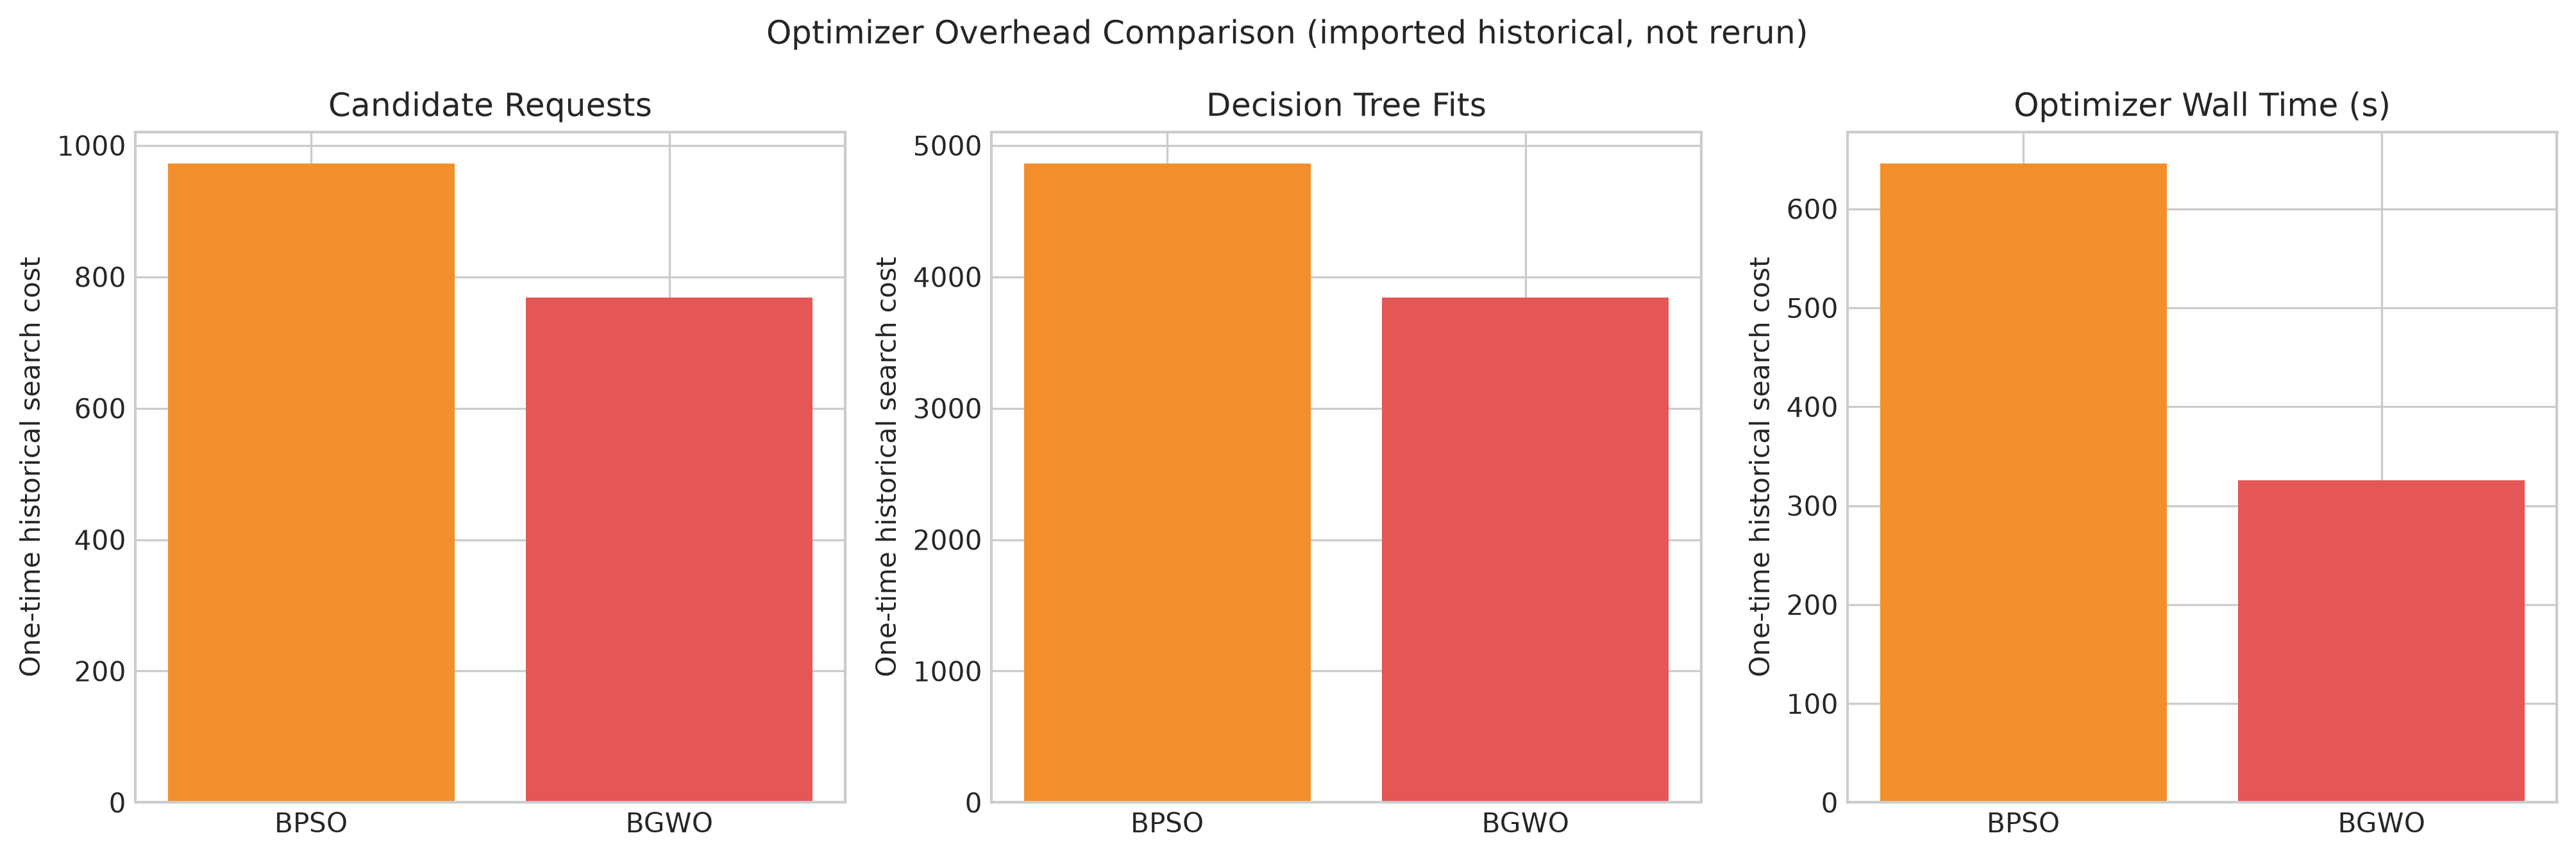

Optimizer overhead provenance: ['IMPORTED_HISTORICAL']


In [15]:
overhead = pd.read_csv(TABLE_DIR / v09g.TABLE_FILENAMES["optimizer_overhead"])
display(overhead)
display(Image(filename=str(FIGURE_DIR / f"{v09g.FIGURE_NAMES[10]}.png")))
print("Optimizer overhead provenance:", overhead["provenance"].unique().tolist())

## 16. Descriptive Predictive-Resource Tradeoff

Post-lock, descriptive comparison of feature count vs frozen final-test AP (V0.9-E) and measured resources (V0.9-F). It is descriptive only; no multi-objective optimization or ranking is performed.

,dimension,value_type,BPSO-K10,BGWO-K14,interpretation
0,feature_count,structural,10.000000,14.000000,BPSO-K10 locked fewer features than BGWO-K14; ...
1,feature_reduction_vs_k43_percent,structural,76.744186,67.441860,Both reduce the 43-feature space; BPSO-K10 by ...
2,validation_average_precision,validation,0.230285,0.234618,Descriptive validation comparison; not a super...
3,validation_f1,validation,0.203308,0.189644,Descriptive validation comparison.
4,validation_recall,validation,0.318667,0.322667,Descriptive validation comparison.
5,final_test_dt_average_precision,final_test_mean,0.219612,0.226035,Metric-specific final-test means (n=5 pairs); ...
6,final_test_dt_f1,final_test_mean,0.187258,0.179717,Difference is small; the paired 95% CI crosses...
7,final_test_lr_average_precision,final_test_mean,0.050732,0.050810,LR means are very close; metric-specific.
8,final_test_lr_f1,final_test_mean,0.086940,0.088486,LR means are very close; metric-specific.
9,decision_tree_training_wall_time_sec,resource_timing,12.915537,12.623808,Indicative timing proxy; BPSO-K10 stays lighte...


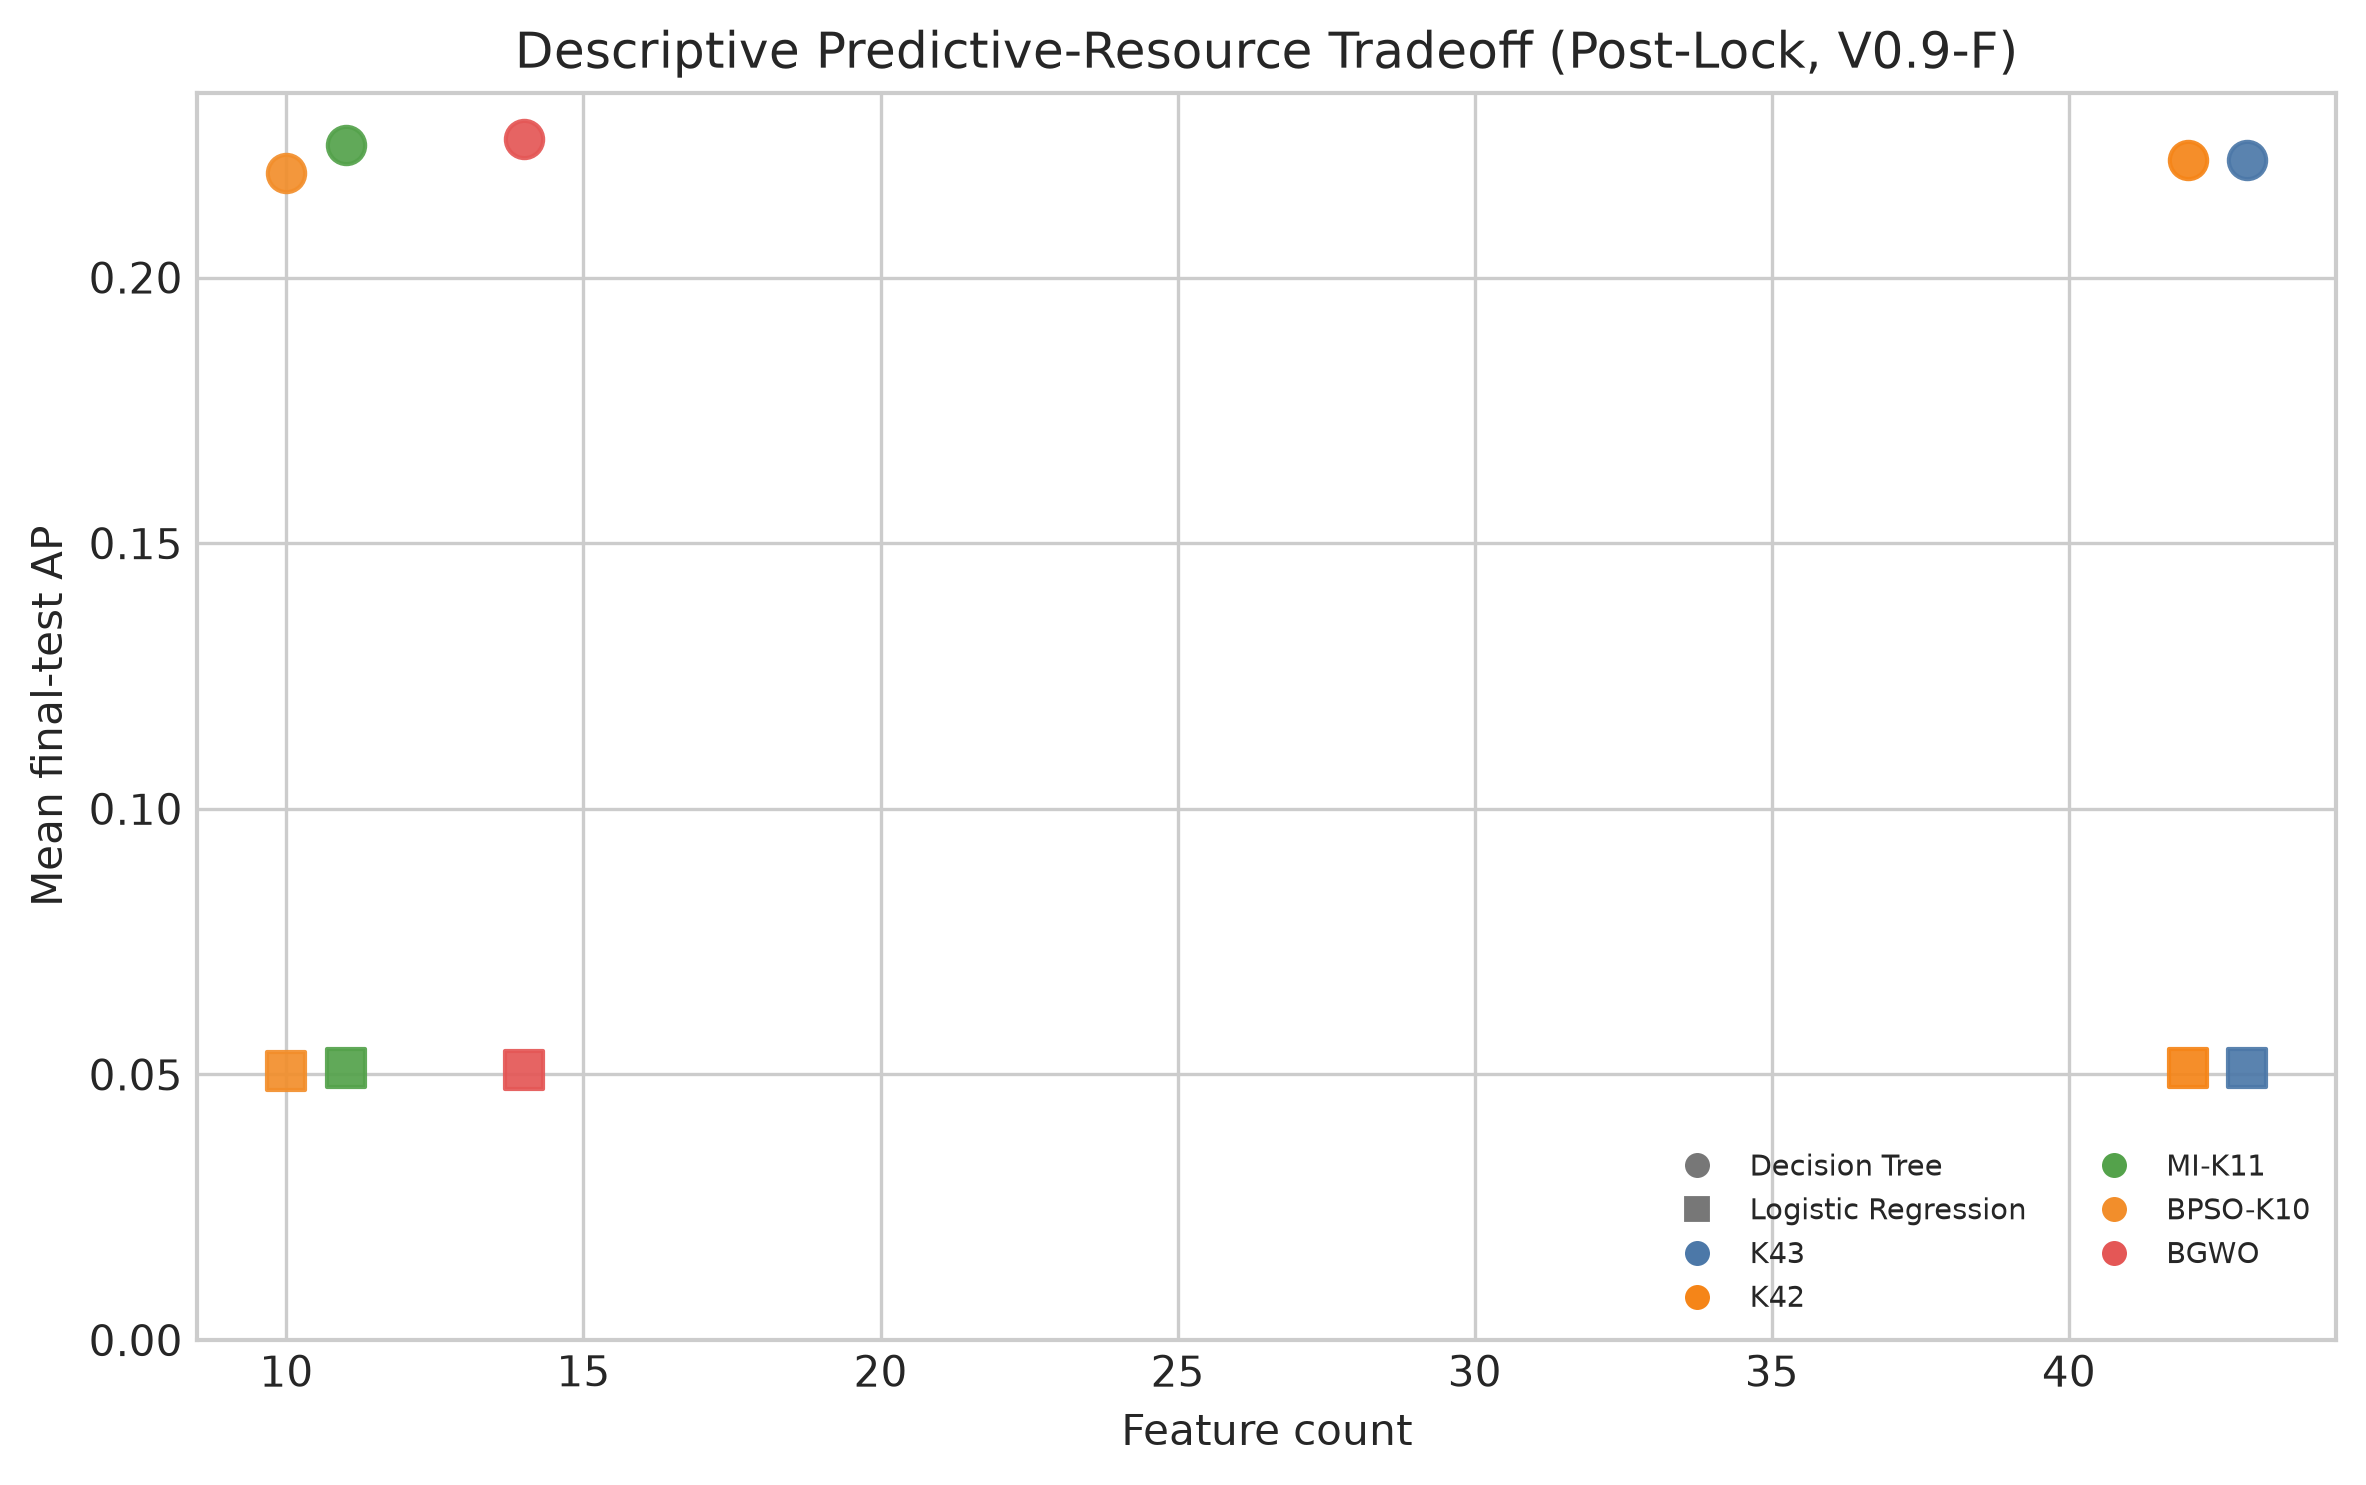

In [16]:
bpso_vs_bgwo = pd.read_csv(TABLE_DIR / v09g.TABLE_FILENAMES["bpso_vs_bgwo"])
display(bpso_vs_bgwo.round(6))
display(Image(filename=str(FIGURE_DIR / f"{v09g.FIGURE_NAMES[11]}.png")))

## 17. Energy, Timing, and Preservation Statements

Standardized reporting statements required by the governed protocol.

In [17]:
print(v09g.ENERGY_STATEMENT)
print()
print(v09g.PRESERVATION_STATEMENT)
print()
v09f_lock = artifacts["v09f_result_lock"]
print("V0.9-F direct energy status:", v09f_lock["direct_energy_status"])
print("V0.9-F Joule-from-CPU/wall estimation performed:", v09f_lock["joule_estimation_from_cpu_or_wall_performed"])
print("V0.9-F observation-level timestamps present:", v09f_lock["observation_level_timestamps_present"])
tradeoff = artifacts["v09f_tradeoff"]
print("Tradeoff classification:", tradeoff["label"])
print("Tradeoff optimization performed:", tradeoff["optimization_performed"])

DIRECT_ENERGY_UNAVAILABLE: no Joule, Watt, kWh, CO2 or CO2e measurements were collected. CPU time, wall-clock time, RSS and throughput are computational resource/efficiency proxies and are not direct physical-energy measurements. No energy value is derived from CPU TDP ratings; TDP multiplication is prohibited in this study.

Preservation margins (AP loss <= 5%, F1 loss <= 5%, Recall loss <= 10%) are preregistered descriptive engineering criteria that governed validation and final-test interpretation. They are operational, not domain-validated clinical or security thresholds, and the final test was never used to reselect or retune anything.

V0.9-F direct energy status: DIRECT_ENERGY_UNAVAILABLE
V0.9-F Joule-from-CPU/wall estimation performed: False
V0.9-F observation-level timestamps present: True
Tradeoff classification: DESCRIPTIVE_POST_HOC_TRADEOFF_ANALYSIS
Tradeoff optimization performed: False


## 18. Main Findings, Limitations, Conclusion and Companion Report

Frozen evidence snapshot is verified unchanged after all reporting output was generated.

In [18]:
evidence_after = v09g.snapshot_evidence(ROOT)
assert evidence_after == evidence_before, "Frozen source evidence changed during V0.9-G!"
print("Frozen evidence unchanged between start and end of V0.9-G (sha256 match).")

Frozen evidence unchanged between start and end of V0.9-G (sha256 match).


In [19]:
print("Main findings (all loaded from frozen V0.8/V0.9 evidence):")
print("  - BGWO winner locked at K=14 (seed 2042) with validation AP 0.2346 / F1 0.1896 / recall 0.3227.")
print("  - BGWO stability: mean pairwise Jaccard {:.4f}; mean K {:.1f} (median {:.1f}).".format(
        stability["jaccard"]["mean"], stability["cardinality"]["mean"], stability["cardinality"]["median"]))
print("  - Final-test preservation holds for both classifiers under the preregistered descriptive margins.")
print("  - BPSO-K10 and BGWO share 3 features (Jaccard {:.6f}); overlap with MI-K11 is seed-dependent (union Jaccard {:.6f}).".format(
        bg_vs_bpso["jaccard"], bg_vs_mi["union_jaccard"]))
print("  - V0.9-F reports computational proxies only; DIRECT_ENERGY_UNAVAILABLE.")
print()
print("Limitations (unchanged from frozen governance):")
print("  - No direct physical-energy measurement; TDP multiplication prohibited.")
print("  - Preservation margins are operational, not domain-validated.")
print("  - MI-K11 is seed-specific; its overlap with BGWO is summarized across 5 seeds.")
print("  - V0.9-D run artifacts record identical best validation means for seeds 2043/2044 on different masks; "
        "reported as-is from the frozen artifacts.")
print()
print("Neutral statement: metric-specific trade-offs are reported for each locked configuration; "
        "no single overall winner, score or ranking is asserted.")
print()
print("Companion scientific report: docs/v09_bgwo_evaluation_report.md")

Main findings (all loaded from frozen V0.8/V0.9 evidence):
  - BGWO winner locked at K=14 (seed 2042) with validation AP 0.2346 / F1 0.1896 / recall 0.3227.
  - BGWO stability: mean pairwise Jaccard 0.3634; mean K 20.6 (median 22.0).
  - Final-test preservation holds for both classifiers under the preregistered descriptive margins.
  - BPSO-K10 and BGWO share 3 features (Jaccard 0.142857); overlap with MI-K11 is seed-dependent (union Jaccard 0.347826).
  - V0.9-F reports computational proxies only; DIRECT_ENERGY_UNAVAILABLE.

Limitations (unchanged from frozen governance):
  - No direct physical-energy measurement; TDP multiplication prohibited.
  - Preservation margins are operational, not domain-validated.
  - MI-K11 is seed-specific; its overlap with BGWO is summarized across 5 seeds.
  - V0.9-D run artifacts record identical best validation means for seeds 2043/2044 on different masks; reported as-is from the frozen artifacts.

Neutral statement: metric-specific trade-offs are repo

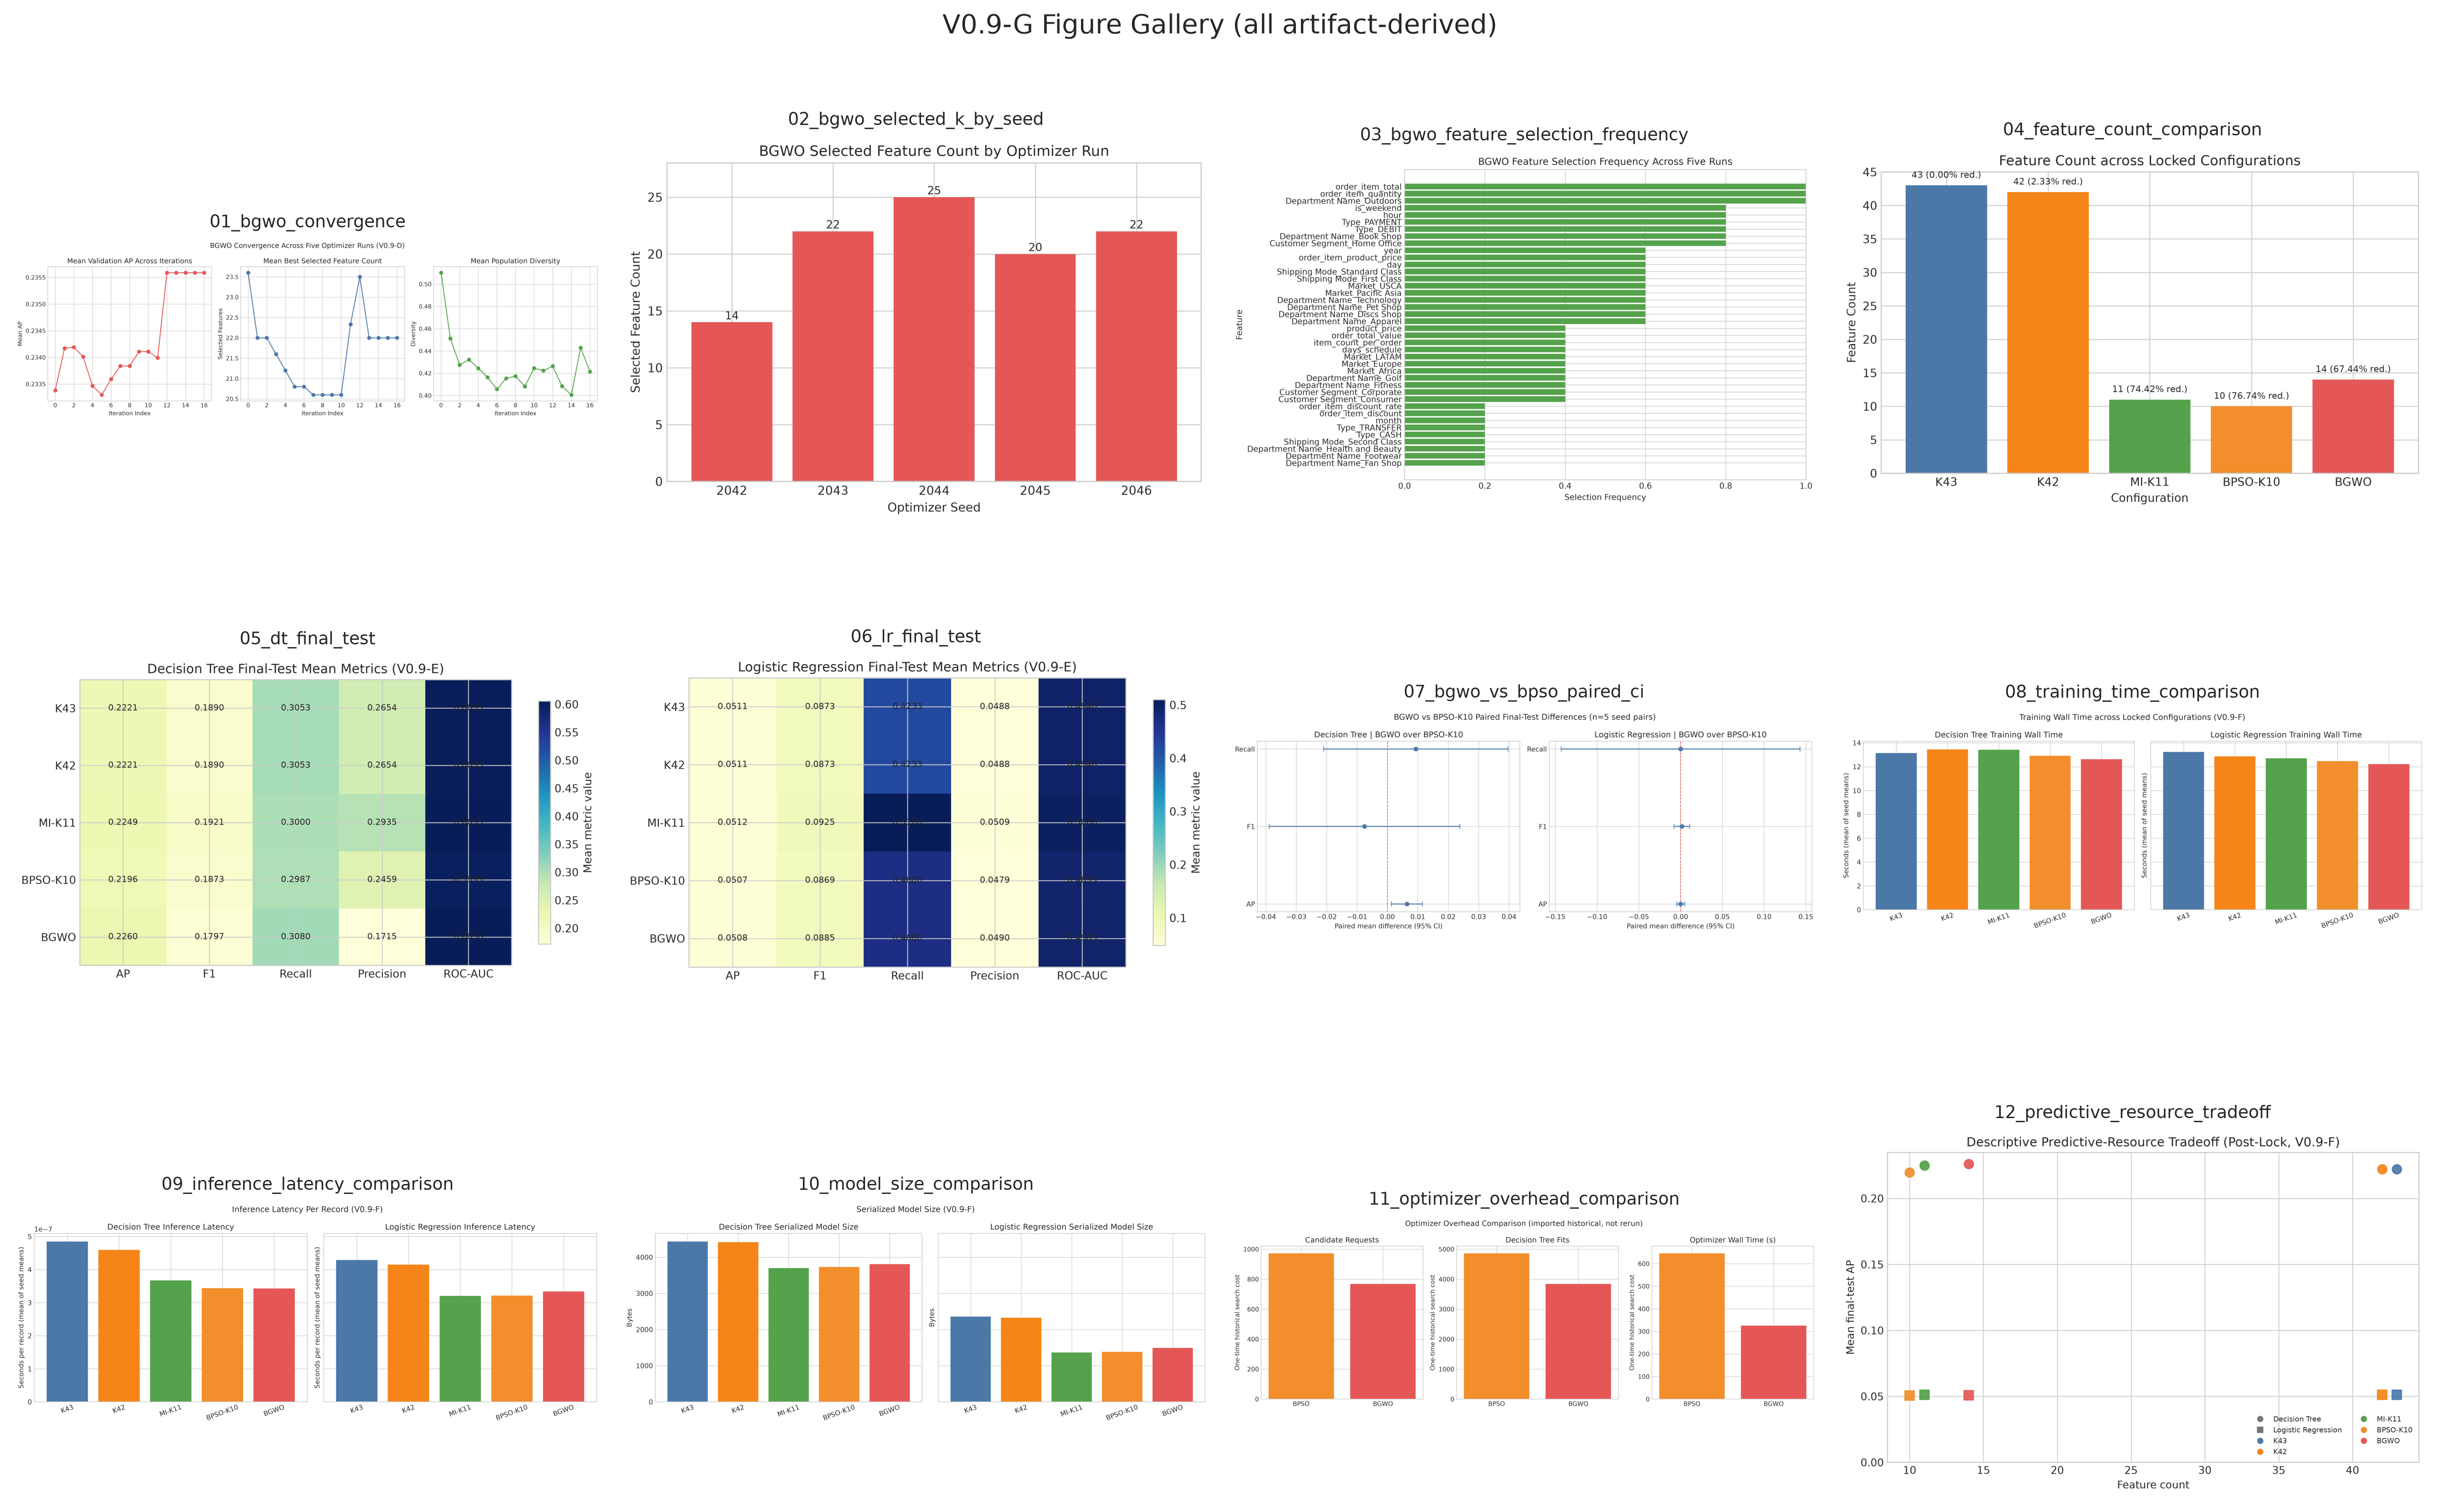

V0.9-G notebook completed without rerunning experiments.


In [20]:
figure_paths = [FIGURE_DIR / f"{name}.png" for name in v09g.FIGURE_NAMES]
assert all(path.is_file() for path in figure_paths)
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
for axis, path in zip(axes.flat, figure_paths):
    axis.imshow(plt.imread(path))
    axis.set_title(path.stem, fontsize=9)
    axis.axis("off")
fig.suptitle("V0.9-G Figure Gallery (all artifact-derived)", fontsize=14)
plt.tight_layout()
import os
import tempfile
from matplotlib.backends.backend_agg import FigureCanvasAgg
from IPython.display import Image
FigureCanvasAgg(fig)
with tempfile.TemporaryDirectory() as _td:
    _gallery = os.path.join(_td, "gallery.png")
    fig.savefig(_gallery, bbox_inches="tight")
    plt.close(fig)
    display(Image(filename=_gallery))
print("V0.9-G notebook completed without rerunning experiments.")